# 🏗️ IaC Benchmark Dataset Builder
> Builds a curated Terraform dataset for LLM IaC-generation benchmarks  
> modelled after **IaC-Eval (NeurIPS 2024)**, **DPIaC-Eval**, and **Multi-IaC-Eval (arXiv 2509.05303)**.

## Pipeline overview
```
1. Clone / fetch repositories
2. Ethical licence filter
3. Collect .tf files → raw dataset
4. Size filter (LOC / token budget)
5. Syntax validation  (TFLint + HCL2 parse)
6. Deployability check (terraform init + terraform plan)
7. AWS targeting filter
8. Aggregate & export
```

### Citation
> *"We use TFLint and Checkov to ensure that all source IaC templates used as the basis of IaC mutation meet standards of IaC best practices and security."*  
> — Davidson et al., Multi-IaC-Eval (2025), §3.5


In [5]:
# ── 1. Install dependencies ────────────────────────────────────────────────────
# Run once; comment out after first execution.
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('requests', 'python-hcl2', 'tiktoken', 'pandas', 'tqdm',
    'PyYAML', 'gitpython', 'boto3', 'tabulate', 'rich', 'matplotlib')

print('✅ Python dependencies installed.')

# ── External tools (install once on system) ────────────────────────────────────
# terraform : https://developer.hashicorp.com/terraform/downloads
# tflint    : https://github.com/terraform-linters/tflint
# checkov   : pip install checkov
# All three must be on $PATH for cells 5 and 6.
for tool in ['terraform', 'tflint', 'checkov']:
    rc = subprocess.run(['which', tool], capture_output=True).returncode
    status = '✅' if rc == 0 else '⚠️  NOT FOUND – install before running cells 5/6'
    print(f'{tool:12s} {status}')


✅ Python dependencies installed.
terraform    ✅
tflint       ✅
checkov      ✅


In [7]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
import os, pathlib

%env AWS_PROFILE=localstack
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = pathlib.Path('./iac_benchmark')          # root workspace
REPOS_DIR  = BASE_DIR / 'repos'                       # git clones land here
DATASET_DIR = BASE_DIR / 'dataset'                    # output CSVs
TMP_DIR    = BASE_DIR / 'tmp_plan'                    # isolated terraform plan dirs
for d in [REPOS_DIR, DATASET_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── GitHub API token (optional – raises rate limit from 60 to 5000 req/hr) ───
GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN', '')     # set in env or paste here
GH_HEADERS   = {'Authorization': f'token {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}

# ── AWS credentials (required for cell 6 – terraform plan) ───────────────────
# Best practice: export AWS_PROFILE=my-sandbox before launching Jupyter.
# A read-only IAM user with no deployment rights is sufficient for `terraform plan`.
AWS_REGION = os.environ.get('AWS_DEFAULT_REGION', 'ap-southeast-2')  # Sydney

# ── Size-filter thresholds (cell 4) ──────────────────────────────────────────
MIN_LOC    = 5        # discard near-empty stubs
MAX_LOC    = 600      # upper bound used by DPIaC-Eval (Level 5 ≈ 200 LoC, we add buffer)
MAX_TOKENS = 8_000    # ~8 k-token context budget leaves room for prompt + response

# ── Token encoder (for LLM token counting) ───────────────────────────────────
import tiktoken
TOKENIZER = tiktoken.get_encoding('cl100k_base')   # GPT-4 / Claude compatible

print('Configuration loaded.')
print(f'  BASE_DIR  : {BASE_DIR.resolve()}')
print(f'  AWS_REGION: {AWS_REGION}')
print(f'  LOC range : [{MIN_LOC}, {MAX_LOC}]  |  max tokens: {MAX_TOKENS}')


env: AWS_PROFILE=localstack
Configuration loaded.
  BASE_DIR  : /Users/iksena/Documents/research/data_analysis/iac_benchmark
  AWS_REGION: ap-southeast-2
  LOC range : [5, 600]  |  max tokens: 8000


In [9]:
# ── 3. Repository Registry ────────────────────────────────────────────────────
# Each entry carries:
#   owner/repo, clone_url, subdirectory to scan ('' = whole repo),
#   primary cloud target, and the licence string reported on GitHub.
#
# Licence eligibility follows Multi-IaC-Eval & IaC-Eval practice:
# only OSI-approved permissive licences that allow redistribution
# in a research dataset are accepted (cell 3b performs the API check).

REPO_REGISTRY = [
    dict(
        slug='hashicorp/terraform-guides',
        subdir='',
        cloud='multi',
        category='official',
        description='HashiCorp official usage patterns across providers'
    ),
    dict(
        slug='GoogleCloudPlatform/terraform-google-examples',
        subdir='',
        cloud='gcp',
        category='official',
        description='GCP examples: GKE, SQL, Vault'
    ),
    dict(
        slug='aws-samples/aws-terraform-best-practices',
        subdir='',
        cloud='aws',
        category='official',
        description='AWS architecture best practices – modularised .tf'
    ),
    dict(
        slug='terraform-aws-modules/terraform-aws-vpc',
        subdir='examples',
        cloud='aws',
        category='official',
        description='Complete, deployable VPC configurations'
    ),
    dict(
        slug='futurice/terraform-examples',
        subdir='',
        cloud='multi',
        category='educational',
        description='Copy-paste recipes for AWS and Azure'
    ),
    dict(
        slug='brokedba/terraform-examples',
        subdir='',
        cloud='multi',
        category='educational',
        description='OCI, AWS, Azure, GCP, Alicloud – broad multi-cloud'
    ),
    dict(
        slug='ContainerSolutions/terraform-examples',
        subdir='',
        cloud='multi',
        category='educational',
        description='Simple, idiomatic – single-file per example (ideal Pass@1)'
    ),
    dict(
        slug='ned1313/terraform-tuesdays',
        subdir='',
        cloud='multi',
        category='educational',
        description='Weekly demos for AWS and Azure'
    ),
    dict(
        slug='alfonsof/terraform-aws-examples',
        subdir='',
        cloud='aws',
        category='specialised',
        description='Step-by-step from single server to full cluster + LB + ASG'
    ),
    dict(
        slug='alfonsof/terraform-azure-examples',
        subdir='',
        cloud='azure',
        category='specialised',
        description='Azure VMs, NSGs, resource management'
    ),
    dict(
        slug='databricks/terraform-databricks-examples',
        subdir='',
        cloud='multi',
        category='specialised',
        description='Databricks data-platform across AWS, Azure, GCP'
    ),
    dict(
        slug='aws-cloudformation/iac-model-evaluation',
        subdir='terraform',
        cloud='aws',
        category='benchmark-source',
        description='High-quality IaC samples specifically curated for LLM evaluation, excluding training data'
    ),
    dict(
        slug='autoiac-project/iac-eval',
        subdir='dataset/terraform',
        cloud='aws',
        category='benchmark-source',
        description='A human-curated dataset of 458 Terraform questions ranging from simple to complex'
    ),
    dict(
        slug='gitmurali/terraform-aws-snippets',
        subdir='',
        cloud='aws',
        category='educational',
        description='Clean, single-directory snippets for VPC, RDS with Secrets Manager, and ECS Fargate'
    ),
    dict(
        slug='garutilorenzo/aws-terraform-examples',
        subdir='examples',
        cloud='aws',
        category='educational',
        description='Provisioning AWS resources using simple main.tf entrypoints for modules'
    ),
    dict(
        slug='ValeriiVasianovych/terraform-iac',
        subdir='',
        cloud='aws',
        category='educational',
        description='Learning resource with practical single-file examples for AWS infrastructure tasks'
    ),
    dict(
        slug='antonputra/tutorials',
        subdir='lessons/040',
        cloud='aws',
        category='educational',
        description='Beginner-friendly single-file examples for EC2, IAM, and Remote State configuration'
    ),
    dict(
        slug='ovotech/terraform-testing-samples',
        subdir='',
        cloud='aws',
        category='best-practices',
        description='Production-grade code samples focusing on IaC testing and verification steps'
    ),
    dict(
        slug='zealvora/terraform-beginner-to-advanced-resource',
        subdir='',
        cloud='aws',
        category='educational',
        description='Course resources with atomic .tf files for EC2, VPC, and Security Groups'
    ),
    dict(
        slug='wardviaene/terraform-course',
        subdir='',
        cloud='aws',
        category='educational',
        description='Demo-based single-file configurations for ELB, AutoScaling, and VPC'
    ),
    dict(
        slug='diodonfrost/terraform-aws-examples',
        subdir='',
        cloud='aws',
        category='educational',
        description='A collection of independent AWS manifests for fast deployment testing'
    ),
    dict(
        slug='brikis98/terraform-up-and-running-code',
        subdir='code/terraform/02-intro-to-terraform-syntax',
        cloud='aws',
        category='educational',
        description='Reference code for single-file Terraform syntax and basic AWS resources'
    ),
    dict(
        slug='aws-samples/cict-terraform-scripts',
        subdir='terraform',
        cloud='aws',
        category='best-practices',
        description='AWS-curated scripts demonstrating verified root-module patterns'
    ),
    dict(
        slug='stack72/terraform-examples',
        subdir='',
        cloud='multi',
        category='educational',
        description='Simple, single-template examples covering AWS, Azure, and core providers'
    )
]

print(f'Registered {len(REPO_REGISTRY)} repositories.')


Registered 24 repositories.


In [11]:
# ── 3b. Ethical Licence Filter ────────────────────────────────────────────────
# Query the GitHub Licence API for each repository.
# Only OSI-approved permissive licences are kept in the pipeline.
# Copyleft (GPL) and proprietary licences are flagged and excluded.
#
# Results are cached to DATASET_DIR/licence_cache.csv so subsequent runs
# skip the GitHub API entirely.  Delete the file to force a fresh check.

import pandas as pd
import requests, json
from rich.console import Console
from rich.table import Table

LICENCE_CACHE = DATASET_DIR / 'licence_cache.csv'

# OSI-approved licences permissible in a research / redistribution context
ALLOWED_SPDX = {
    'MIT', 'MIT-0', 'Apache-2.0', 'BSD-2-Clause', 'BSD-3-Clause',
    'ISC', 'MPL-2.0', 'CC0-1.0', 'Unlicense', 'WTFPL'
}
# Copyleft / viral licences – included in benchmark ONLY if licence explicitly
# permits use in academic datasets (check repo NOTICE/README manually)
COPYLEFT_SPDX = {'GPL-2.0', 'GPL-3.0', 'LGPL-2.1', 'LGPL-3.0', 'AGPL-3.0'}

def fetch_licence(slug: str) -> dict:
    url = f'https://api.github.com/repos/{slug}/license'
    r = requests.get(url, headers=GH_HEADERS, timeout=15)
    if r.status_code == 200:
        data = r.json()
        spdx = data.get('license', {}).get('spdx_id', 'NOASSERTION')
        name = data.get('license', {}).get('name', 'Unknown')
        return {'spdx': spdx, 'name': name}
    elif r.status_code == 404:
        return {'spdx': 'NONE', 'name': 'No licence file found'}
    else:
        return {'spdx': 'ERROR', 'name': f'HTTP {r.status_code}'}

# ── Load from cache if available, otherwise hit GitHub API ───────────────────
if LICENCE_CACHE.exists():
    df_licence_cache = pd.read_csv(LICENCE_CACHE, index_col='slug')
    _cache = df_licence_cache.to_dict('index')   # {slug: {spdx, name, eligible, note}}
    print(f'✅ Loaded licence cache from {LICENCE_CACHE} ({len(_cache)} entries)')
    print('   Delete the file to force a fresh GitHub API check.\n')
else:
    _cache = {}
    print('No licence cache found — querying GitHub API…\n')

console = Console()
table = Table(title='Licence Eligibility Check', show_lines=True)
table.add_column('Repository',  style='cyan')
table.add_column('SPDX',        style='yellow')
table.add_column('Eligible?',   style='bold')
table.add_column('Source')
table.add_column('Notes')

APPROVED_REPOS = []
EXCLUDED_REPOS = []
cache_rows     = []

for repo in REPO_REGISTRY:
    slug = repo['slug']

    # ── Use cache hit or fetch live ───────────────────────────────────────────
    if slug in _cache:
        cached      = _cache[slug]
        spdx        = cached['spdx']
        name        = cached['name']
        data_source = '📂 cache'
    else:
        lic         = fetch_licence(slug)
        spdx        = lic['spdx']
        name        = lic['name']
        data_source = '🌐 API'

    repo['licence_spdx'] = spdx
    repo['licence_name'] = name

    if spdx in ALLOWED_SPDX:
        eligible = '✅ YES'
        note     = 'Permissive – clear for redistribution'
        repo['licence_eligible'] = True
        APPROVED_REPOS.append(repo)
    elif spdx in COPYLEFT_SPDX:
        eligible = '⚠️  COPYLEFT'
        note     = 'Review NOTICE/README for dataset clause'
        repo['licence_eligible'] = True
        APPROVED_REPOS.append(repo)
    else:
        eligible = '❌ EXCLUDED'
        note     = f'No/unknown licence ({spdx})'
        repo['licence_eligible'] = False
        EXCLUDED_REPOS.append(repo)

    table.add_row(slug, spdx, eligible, data_source, note)

    cache_rows.append({
        'slug'     : slug,
        'spdx'     : spdx,
        'name'     : name,
        'eligible' : repo['licence_eligible'],
        'note'     : note,
    })

console.print(table)
print(f'\nApproved: {len(APPROVED_REPOS)} | Excluded: {len(EXCLUDED_REPOS)}')
print('\nManually override repo["licence_eligible"] = True for copyleft repos')
print('after confirming that the licence allows academic dataset redistribution.')

# ── Save / refresh cache CSV ──────────────────────────────────────────────────
df_new_cache = pd.DataFrame(cache_rows).set_index('slug')
df_new_cache.to_csv(LICENCE_CACHE)
print(f'\n💾 Licence cache saved → {LICENCE_CACHE}')

✅ Loaded licence cache from iac_benchmark/dataset/licence_cache.csv (24 entries)
   Delete the file to force a fresh GitHub API check.



                                             Licence Eligibility Check                                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Repository                          ┃ SPDX        ┃ Eligible?   ┃ Source   ┃ Notes                              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ hashicorp/terraform-guides          │ MPL-2.0     │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ GoogleCloudPlatform/terraform-goog… │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-samples/aws-terraform-best-pra… │ NOASSERTION │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NOASSERTION)   │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ terraform-aws-modules/terraform-aw… │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ futurice/terraform-examples         │ MIT         │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ brokedba/terraform-examples         │ GPL-3.0     │ ⚠️  COPYLEFT │ 📂 cache │ Review NOTICE/README for dataset   │
│                                     │             │             │          │ clause                             │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ ContainerSolutions/terraform-examp… │ NONE        │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NONE)          │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ ned1313/terraform-tuesdays          │ MIT         │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ alfonsof/terraform-aws-examples     │ MIT         │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ alfonsof/terraform-azure-examples   │ MIT         │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ databricks/terraform-databricks-ex… │ NOASSERTION │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NOASSERTION)   │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-cloudformation/iac-model-evalu… │ MIT-0       │ ✅ YES      │ 📂 cache │


Approved: 18 | Excluded: 6

Manually override repo["licence_eligible"] = True for copyleft repos
after confirming that the licence allows academic dataset redistribution.

💾 Licence cache saved → iac_benchmark/dataset/licence_cache.csv


In [13]:
# ── 3c. Merge IaC-Eval (HuggingFace) into REPO_REGISTRY corpus ───────────────
#
# FIX (vs original): The original cell wrote each Reference output directly to
# SINGLE_ROOT_DIR and set is_merged=False/file_count=1 unconditionally, bypassing
# the single-root normalisation and size-filter steps.
#
# Correct approach:
#   1. Load & deduplicate as before.
#   2. Build IAC_EVAL_HF_RECORDS with the df_raw schema (NOT the df_roots/normalised
#      schema) so the records enter the pipeline at cell-06 (size filter) and
#      carry difficulty assigned there — NOT pre-assigned here.
#   3. Do NOT write files to SINGLE_ROOT_DIR here; that is cell-05b's job.
#   4. Do NOT pre-assign difficulty; cell-06 assigns it uniformly for all rows.
#   5. Remove the GitHub clone entry from REPO_REGISTRY as before.
#
# The IAC_EVAL_HF_RECORDS list is consumed by cell-05c which injects rows into
# df_raw AFTER cell-05b has built the normalised single-root set.

import pathlib, json, re, hashlib
import pandas as pd
import pyarrow.parquet as pq

def count_tokens(text: str) -> int:
    return len(TOKENIZER.encode(text))
BASE_DIR   = pathlib.Path('./iac_benchmark') 
# ── Paths ──────────────────────────────────────────────────────────────────────
IAC_EVAL_HF_DIR = BASE_DIR / 'iac_eval_hf'

_parquet_files = sorted((IAC_EVAL_HF_DIR / 'data').glob('*.parquet'))
_jsonl_file    = IAC_EVAL_HF_DIR / 'data' / 'train.jsonl'

if _parquet_files:
    df_iac_eval = pd.concat(
        [pq.read_table(str(f)).to_pandas() for f in _parquet_files],
        ignore_index=True
    )
    _fmt = f'Parquet ({len(_parquet_files)} shard(s))'
elif _jsonl_file.exists():
    df_iac_eval = pd.read_json(_jsonl_file, lines=True)
    _fmt = 'JSONL'
else:
    raise FileNotFoundError(
        f"IaC-Eval dataset not found under {IAC_EVAL_HF_DIR}/data/\n"
        "Download with:\n"
        "  from datasets import load_dataset\n"
        "  ds = load_dataset('autoiac-project/iac-eval')\n"
        "  ds['train'].to_parquet('./iac_benchmark/iac_eval_hf/data/train.parquet')\n"
        "Or export from: https://huggingface.co/datasets/autoiac-project/iac-eval/viewer/default"
    )

print(f'Loaded IaC-Eval from {_fmt}: {len(df_iac_eval):,} rows')
print(f'Columns: {list(df_iac_eval.columns)}')

# ── Column aliases ─────────────────────────────────────────────────────────────
_CODE_COL   = 'Reference output'
_PROMPT_COL = 'Prompt'
_DIFF_COL   = 'Difficulty'
_INTENT_COL = 'Intent'
_REGO_COL   = 'Rego intent'
_RES_COL    = 'Resource'

_required = {_CODE_COL, _PROMPT_COL, _DIFF_COL}
_missing  = _required - set(df_iac_eval.columns)
if _missing:
    raise ValueError(
        f"Expected columns missing from IaC-Eval dataset: {_missing}\n"
        f"Available: {list(df_iac_eval.columns)}"
    )

# ── Build records in the df_RAW schema (NOT df_roots/normalised schema) ────────
# Each Reference output is a single-file Terraform template → file_path acts as
# a synthetic relative path;  parent_dir = '' so cell-05b treats it as a
# one-file root and keeps it as-is (no merging needed).
# difficulty and dest_file are intentionally ABSENT here — they are assigned by
# cell-06 (size filter) and cell-05b (normalisation) respectively.

IAC_EVAL_HF_RECORDS = []

for idx, row in df_iac_eval.iterrows():
    content = str(row.get(_CODE_COL) or '').strip()
    if not content:
        continue

    resource_raw = str(row.get(_RES_COL, f'task_{idx}')).strip()
    safe_stem    = re.sub(r'[^\w\-]', '_', resource_raw)[:50] or f'task_{idx}'
    # Unique synthetic path that mimics a repo file_path
    synthetic_path = f'autoiac-project__iac-eval/{safe_stem}_{idx}.tf'

    loc    = content.count('\n') + 1
    tokens = count_tokens(content)

    IAC_EVAL_HF_RECORDS.append({
        # ── df_raw schema (matches cell-06 / cell-05b input) ───────────────────
        'source_slug'     : 'autoiac-project/iac-eval',
        'source_category' : 'benchmark-source',
        'primary_cloud'   : 'aws',
        'licence_spdx'    : 'MIT',
        'file_path'       : synthetic_path,
        'github_url'      : 'https://huggingface.co/datasets/autoiac-project/iac-eval/viewer/default',
        'content'         : content,
        'loc'             : loc,
        'tokens'          : tokens,
        # parent_dir = '' → cell-05b sees this as a single-file root; no merge
        'parent_dir'      : '',

        # ── IaC-Eval-native bonus columns ──────────────────────────────────────
        'iac_eval_resource' : str(row.get(_RES_COL,    '')).strip(),
        'iac_eval_prompt'   : str(row.get(_PROMPT_COL, '')).strip(),
        'iac_eval_intent'   : str(row.get(_INTENT_COL, '')).strip(),
        'iac_eval_rego'     : str(row.get(_REGO_COL,   '')).strip(),
        'iac_eval_level'    : str(row.get(_DIFF_COL,   '')).strip().lower(),
    })

df_iac_eval_raw = pd.DataFrame(IAC_EVAL_HF_RECORDS)

# ── Deduplicate on content hash ────────────────────────────────────────────────
df_iac_eval_raw['_hash'] = df_iac_eval_raw['content'].apply(
    lambda c: hashlib.md5(c.encode()).hexdigest()
)
before_dedup    = len(df_iac_eval_raw)
df_iac_eval_raw = (df_iac_eval_raw
    .drop_duplicates(subset='_hash', keep='first')
    .drop(columns='_hash')
    .reset_index(drop=True)
)
IAC_EVAL_HF_RECORDS = df_iac_eval_raw.to_dict('records')

print(f'\nNormalised {before_dedup:,} IaC-Eval rows')
print(f'Duplicates removed (identical content): {before_dedup - len(df_iac_eval_raw):,}')
print(f'Unique templates retained            : {len(df_iac_eval_raw):,}')
print(f'\nLevel distribution (original label):')
print(df_iac_eval_raw['iac_eval_level'].value_counts().to_string())
print(f'\nTop 10 resources:')
print(df_iac_eval_raw['iac_eval_resource'].value_counts().head(10).to_string())

# ── Deregister the GitHub clone of the same repo ──────────────────────────────
_DEREGISTER_SLUG = 'autoiac-project/iac-eval'
_before = len(REPO_REGISTRY)
REPO_REGISTRY = [r for r in REPO_REGISTRY if r['slug'] != _DEREGISTER_SLUG]
print(f'\nDeregistered "{_DEREGISTER_SLUG}" from REPO_REGISTRY '
      f'({_before} → {len(REPO_REGISTRY)} repos) to avoid double-counting.')


Loaded IaC-Eval from Parquet (1 shard(s)): 458 rows
Columns: ['Resource', 'Prompt', 'Rego intent', 'Difficulty', 'Reference output', 'Intent']

Normalised 458 IaC-Eval rows
Duplicates removed (identical content): 90
Unique templates retained            : 368

Level distribution (original label):
iac_eval_level
2    86
3    85
6    55
5    52
4    50
1    40

Top 10 resources:
iac_eval_resource
aws_db_instance                                                                                                                13
aws_instance, aws_lb, aws_lb_listener, aws_lb_target_group, aws_lb_target_group_attachment, aws_subnet, aws_subnet, aws_vpc    10
aws_dynamodb_table                                                                                                             10
aws_lightsail_instance                                                                                                          6
aws_lex_bot, aws_lex_intent                                                        

In [15]:
# ── 4. Clone / Update Repositories ───────────────────────────────────────────
# Uses shallow clone (depth=1) to save disk space.
# If the directory already exists, pulls the latest changes instead.

import git
from tqdm.notebook import tqdm

def clone_or_pull(slug: str, dest: pathlib.Path) -> bool:
    url = f'https://github.com/{slug}.git'
    try:
        if dest.exists():
            r = git.Repo(dest)
            r.remotes.origin.pull(depth=1)
            return True
        else:
            git.Repo.clone_from(url, dest, depth=1, single_branch=True)
            return True
    except Exception as e:
        print(f'  ⚠️  {slug}: {e}')
        return False

eligible = [r for r in REPO_REGISTRY if r.get('licence_eligible')]
print(f'Cloning {len(eligible)} approved repositories…\n')

for repo in tqdm(eligible, desc='Cloning'):
    slug   = repo['slug']
    dest   = REPOS_DIR / slug.replace('/', '__')
    repo['local_path'] = str(dest)
    ok = clone_or_pull(slug, dest)
    print(f'  {"✅" if ok else "❌"} {slug}')

print('\nClone phase complete.')


Cloning 17 approved repositories…



Cloning:   0%|          | 0/17 [00:00<?, ?it/s]

  ✅ hashicorp/terraform-guides
  ✅ GoogleCloudPlatform/terraform-google-examples
  ✅ terraform-aws-modules/terraform-aws-vpc
  ✅ futurice/terraform-examples
  ✅ brokedba/terraform-examples
  ✅ ned1313/terraform-tuesdays
  ✅ alfonsof/terraform-aws-examples
  ✅ alfonsof/terraform-azure-examples
  ✅ aws-cloudformation/iac-model-evaluation
  ✅ gitmurali/terraform-aws-snippets
  ✅ garutilorenzo/aws-terraform-examples
  ✅ ValeriiVasianovych/terraform-iac
  ✅ antonputra/tutorials
  ✅ ovotech/terraform-testing-samples
  ✅ diodonfrost/terraform-aws-examples
  ✅ brikis98/terraform-up-and-running-code
  ✅ aws-samples/cict-terraform-scripts

Clone phase complete.


In [23]:
# # ── 4b. ALTERNATIVE – Fetch .tf files via GitHub API (no disk clone) ─────────
# # Useful when you only want to sample files without cloning multi-GB repos.
# # Skip this cell if you used cell 4 (clone).

# import requests, base64, time

# def api_get(url: str) -> dict | list | None:
#     r = requests.get(url, headers=GH_HEADERS, timeout=20)
#     if r.status_code == 403:                     # rate limited
#         reset = int(r.headers.get('X-RateLimit-Reset', time.time() + 60))
#         wait  = max(reset - int(time.time()), 5)
#         print(f'Rate-limited – waiting {wait}s…')
#         time.sleep(wait)
#         return api_get(url)
#     return r.json() if r.ok else None

# def list_tf_files(slug: str, path: str = '', ref: str = 'HEAD') -> list[dict]:
#     """Recursively list all .tf files in a GitHub repo subtree."""
#     url   = f'https://api.github.com/repos/{slug}/git/trees/{ref}?recursive=1'
#     tree  = api_get(url)
#     if not tree:
#         return []
#     files = [
#         item for item in tree.get('tree', [])
#         if item['type'] == 'blob'
#         and item['path'].endswith('.tf')
#         and (path == '' or item['path'].startswith(path))
#     ]
#     return files

# def fetch_file_content(slug: str, sha: str) -> str:
#     """Fetch raw file content by blob SHA."""
#     url  = f'https://api.github.com/repos/{slug}/git/blobs/{sha}'
#     blob = api_get(url)
#     if not blob:
#         return ''
#     return base64.b64decode(blob['content']).decode('utf-8', errors='replace')

# # Example: fetch files from one repo without cloning
# # slug = 'ContainerSolutions/terraform-examples'
# # files = list_tf_files(slug)
# # content = fetch_file_content(slug, files[0]['sha'])
# print('API-fetch helpers defined. Use list_tf_files() / fetch_file_content() as needed.')


In [17]:
# ── 5. Collect .tf Files → Raw Dataset ───────────────────────────────────────
# Walks approved cloned repos and harvests every .tf file.
# Records: path, source slug, cloud target, content, LOC, tokens.

import pandas as pd

RAW_RECORDS = []

for repo in eligible:
    if 'local_path' not in repo:
        continue
    root = pathlib.Path(repo['local_path'])
    subdir = repo.get('subdir', '')
    scan_root = root / subdir if subdir else root

    for tf_path in scan_root.rglob('*.tf'):
        try:
            content = tf_path.read_text(encoding='utf-8', errors='replace')
        except Exception:
            continue

        loc    = content.count('\n') + 1
        tokens = count_tokens(content)
        # Relative path within repo (for reproducibility)
        rel    = str(tf_path.relative_to(root))

        RAW_RECORDS.append({
            'source_slug'       : repo['slug'],
            'source_category'   : repo['category'],
            'primary_cloud'     : repo['cloud'],
            'licence_spdx'      : repo['licence_spdx'],
            'file_path'         : rel,
            'github_url'        : f'https://github.com/{repo["slug"]}/blob/HEAD/{rel}',
            'content'           : content,
            'loc'               : loc,
            'tokens'            : tokens,
        })

df_raw = pd.DataFrame(RAW_RECORDS)
print(f'Raw collection: {len(df_raw):,} .tf files')
print(df_raw[['source_slug','primary_cloud','loc','tokens']]
      .groupby('source_slug').agg({'loc':'mean', 'tokens':'mean', 'primary_cloud':'first'})
      .round(1).to_string())


Raw collection: 1,713 .tf files
                                                 loc  tokens primary_cloud
source_slug                                                               
GoogleCloudPlatform/terraform-google-examples  103.4   610.9           gcp
ValeriiVasianovych/terraform-iac                28.8   201.6           aws
alfonsof/terraform-aws-examples                 19.2   125.2           aws
alfonsof/terraform-azure-examples               52.6   376.1         azure
antonputra/tutorials                            13.2    73.2           aws
aws-cloudformation/iac-model-evaluation         35.2   256.7           aws
aws-samples/cict-terraform-scripts              35.9   227.5           aws
brikis98/terraform-up-and-running-code          46.6   263.9           aws
brokedba/terraform-examples                     70.0   597.4         multi
diodonfrost/terraform-aws-examples              31.0   209.0           aws
futurice/terraform-examples                     51.0   394.5        

In [19]:
# ── 5b. Single-Root Template Normalisation ────────────────────────────────────
# Groups collected .tf files by parent directory (= one Terraform root),
# merges multi-file roots into a single self-contained string, normalises
# all whitespace variants so duplicates that differ only in newlines/spaces
# are detected and removed before any downstream step.

import hashlib, re, shutil
from pathlib import Path

SINGLE_ROOT_DIR = BASE_DIR / 'single_root_templates'
SINGLE_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# ── Tunables ──────────────────────────────────────────────────────────────────
MAX_FILES_PER_ROOT = 10    # roots with more files are likely framework modules
MERGE_MULTI_FILE   = True  # False → keep only single-file roots

# ── Normalisation ─────────────────────────────────────────────────────────────
# Applied to EVERY file's content BEFORE merging and BEFORE hashing.
# Order matters: unify endings first, then expand tabs, then strip trailing
# whitespace per line, then collapse excess blank lines, then trim file edges.

def normalise_hcl(text: str) -> str:
    """
    Normalise HCL content so whitespace-only variants produce identical output.
    Semantic content (comments, values, identifiers) is never altered.
    """
    # 1. Unify line endings (CRLF → LF, lone CR → LF)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    # 2. Expand tabs to 2 spaces (HCL/Terraform formatter convention)
    text = text.replace('\t', '  ')
    # 3. Strip trailing whitespace on every line
    text = '\n'.join(line.rstrip() for line in text.split('\n'))
    # 4. Collapse 3+ consecutive blank lines → exactly 2
    text = re.sub(r'\n{3,}', '\n\n', text)
    # 5. Strip leading/trailing blank lines from the whole file
    return text.strip()

def content_hash(text: str) -> str:
    """SHA-256 of already-normalised content."""
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

# ── Skip-path predicate ───────────────────────────────────────────────────────
_SKIP_RE = re.compile(
    r'(^|/)(\.|__pycache__|\.git|\.terraform|\.terragrunt-cache'
    r'|tests?|fixtures?|testdata|vendor|node_modules)(/|$)',
    re.IGNORECASE,
)

def _should_skip(rel_path: str) -> bool:
    return bool(_SKIP_RE.search(rel_path))

# ── Pre-normalise every raw record's content ──────────────────────────────────
n_before = len(df_raw)
print(f"▶ Before normalisation  : {n_before:,} raw .tf records")

df_raw = df_raw[~df_raw['file_path'].apply(_should_skip)].copy()
n_after_skip = len(df_raw)
print(f"  Skipped (test/fixture): {n_before - n_after_skip:,}")
print(f"  Remaining             : {n_after_skip:,}")

# Normalise in-place — downstream merge uses 'content_norm' not 'content'
df_raw['content_norm'] = df_raw['content'].apply(normalise_hcl)

# ── Group by (source_slug, parent_dir) ────────────────────────────────────────
df_raw['parent_dir'] = df_raw['file_path'].apply(lambda p: str(Path(p).parent))

groups = df_raw.groupby(['source_slug', 'parent_dir'])
print(f"\n▶ Unique Terraform roots: {len(groups):,}")

normalised_records = []
copy_stats = {'kept_single': 0, 'merged': 0, 'skipped_large': 0, 'skipped_no_multi': 0}

# ── Canonical file-sort order within a merged root ────────────────────────────
_PRIORITY = {
    'main.tf': 0, 'variables.tf': 1, 'outputs.tf': 2,
    'providers.tf': 3, 'versions.tf': 4, 'locals.tf': 5,
}

for (slug, parent), group in tqdm(groups, desc='Normalising roots'):

    # Skip framework-level roots that are too large to be standalone examples
    if len(group) > MAX_FILES_PER_ROOT:
        copy_stats['skipped_large'] += 1
        continue

    if len(group) == 1 or not MERGE_MULTI_FILE:
        if len(group) > 1 and not MERGE_MULTI_FILE:
            copy_stats['skipped_no_multi'] += 1
            continue
        row          = group.iloc[0]
        # Use already-normalised content; no further whitespace work needed
        merged_norm  = row['content_norm']
        is_merged    = False
        origin_files = [row['file_path']]
        copy_stats['kept_single'] += 1
    else:
        ordered = sorted(
            group.itertuples(),
            key=lambda r: (_PRIORITY.get(Path(r.file_path).name, 99), r.file_path),
        )
        sections = []
        for r in ordered:
            fname = Path(r.file_path).name
            # Section separator is itself a normalised single blank line
            header = f'# ── {fname} ──────────────────────────────────────────'
            # r.content_norm is already normalised — no re-normalisation needed
            sections.append(f'{header}\n{r.content_norm}')
        # Join sections with exactly ONE blank line (2 newlines) between them
        merged_norm  = '\n\n'.join(sections)
        # Final pass: collapse any accidental 3+ blank lines at section seams
        merged_norm  = re.sub(r'\n{3,}', '\n\n', merged_norm).strip()
        is_merged    = True
        origin_files = [r.file_path for r in ordered]
        copy_stats['merged'] += 1

    row0        = group.iloc[0]
    loc         = merged_norm.count('\n') + 1
    tokens      = count_tokens(merged_norm)
    folder_name = (parent.replace('/', '__').replace(' ', '_') or 'ROOT')
    dest_slug   = slug.replace('/', '__')
    chash       = content_hash(merged_norm)

    dest_dir  = SINGLE_ROOT_DIR / dest_slug
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_file = dest_dir / f'{folder_name}.tf'
    dest_file.write_text(merged_norm, encoding='utf-8')

    normalised_records.append({
        'source_slug'    : slug,
        'source_category': row0['source_category'],
        'primary_cloud'  : row0['primary_cloud'],
        'licence_spdx'   : row0['licence_spdx'],
        'root_path'      : str(Path(slug) / parent) if parent else slug,
        'origin_files'   : ' | '.join(origin_files),
        'file_count'     : len(origin_files),
        'is_merged'      : is_merged,
        'dest_file'      : str(dest_file.relative_to(BASE_DIR)),
        'github_url'     : (f'https://github.com/{slug}/tree/HEAD/{parent}'
                            if parent else f'https://github.com/{slug}'),
        'content'        : merged_norm,   # normalised content replaces raw
        'content_hash'   : chash,
        'loc'            : loc,
        'tokens'         : tokens,
    })

df_roots = pd.DataFrame(normalised_records)

# ── Exact-duplicate removal (post-merge, hash on fully normalised content) ────
n_before_dedup = len(df_roots)
df_roots = df_roots.drop_duplicates(subset='content_hash', keep='first').copy()
n_after_dedup  = len(df_roots)

# ── Summary ───────────────────────────────────────────────────────────────────
print('=' * 60)
print('SINGLE-ROOT NORMALISATION SUMMARY')
print('=' * 60)
print(f"  Input .tf records          : {n_after_skip:>6,}")
print(f"  Unique roots found         : {len(groups):>6,}")
print(f"  ✅  Kept (single-file)     : {copy_stats['kept_single'] - copy_stats['merged']:>6,}")
print(f"  🔀  Merged (multi-file)    : {copy_stats['merged']:>6,}")
print(f"  ⏭️   Skipped (>{MAX_FILES_PER_ROOT} files)   : {copy_stats['skipped_large']:>6,}")
print(f"  🗑️   Exact duplicates removed: {n_before_dedup - n_after_dedup:>6,}")
print(f"  ▶ Output templates         : {n_after_dedup:>6,}")
print(f"\nOutput folder : {SINGLE_ROOT_DIR.resolve()}")
print()
print('Top 5 sources by template count:')
print(df_roots.groupby('source_slug')['root_path']
      .count().sort_values(ascending=False).head(5).to_string())
print()
print('Merged vs single-file breakdown:')
print(df_roots['is_merged'].value_counts()
      .rename({True: 'merged', False: 'single-file'}).to_string())

# ── Promote to df_raw for all downstream cells ────────────────────────────────
df_raw = df_roots.copy()
print('\n✅ df_raw replaced with normalised single-root dataset.')
print('   All downstream cells will use normalised content.')

# ── Inject IaC-Eval HF dataset rows (if collected) ────────────────────────────
if 'IAC_EVAL_HF_RECORDS' in dir() and IAC_EVAL_HF_RECORDS:
    df_iac_hf = (
        pd.DataFrame(IAC_EVAL_HF_RECORDS)
        .reindex(columns=df_raw.columns)
    )
    # Normalise HF content too — same pipeline, same guarantee
    df_iac_hf['content'] = df_iac_hf['content'].apply(normalise_hcl)
    df_iac_hf['content_hash'] = df_iac_hf['content'].apply(content_hash)
    df_raw = pd.concat([df_raw, df_iac_hf], ignore_index=True)
    # Remove cross-source duplicates introduced by HF injection
    before_hf_dedup = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset='content_hash', keep='first').copy()
    print(f'\n  + {len(df_iac_hf):,} IaC-Eval HF rows merged')
    print(f'  - {before_hf_dedup - len(df_raw):,} cross-source duplicates removed')
    print(f'  ▶ df_raw total: {len(df_raw):,}')

▶ Before normalisation  : 1,713 raw .tf records
  Skipped (test/fixture): 4
  Remaining             : 1,709

▶ Unique Terraform roots: 509


Normalising roots:   0%|          | 0/509 [00:00<?, ?it/s]

SINGLE-ROOT NORMALISATION SUMMARY
  Input .tf records          :  1,709
  Unique roots found         :    509
  ✅  Kept (single-file)     :   -179
  🔀  Merged (multi-file)    :    336
  ⏭️   Skipped (>10 files)   :     16
  🗑️   Exact duplicates removed:     13
  ▶ Output templates         :    480

Output folder : /Users/iksena/Documents/research/data_analysis/iac_benchmark/single_root_templates

Top 5 sources by template count:
source_slug
ned1313/terraform-tuesdays          223
ValeriiVasianovych/terraform-iac     64
hashicorp/terraform-guides           45
alfonsof/terraform-aws-examples      31
brokedba/terraform-examples          30

Merged vs single-file breakdown:
is_merged
merged         327
single-file    153

✅ df_raw replaced with normalised single-root dataset.
   All downstream cells will use normalised content.

  + 368 IaC-Eval HF rows merged
  - 2 cross-source duplicates removed
  ▶ df_raw total: 846


In [21]:
# ── 5c. Inject IaC-Eval (HuggingFace) into normalised df_raw ─────────────────
# FIX: IAC_EVAL_HF_RECORDS are now in df_raw schema (not df_roots schema), so
# they go through cell-05b normalisation. This cell now ONLY handles cross-source
# deduplication and appending — no schema coercion needed.

import hashlib

if not ('IAC_EVAL_HF_RECORDS' in dir() and IAC_EVAL_HF_RECORDS):
    print('⚠️  IAC_EVAL_HF_RECORDS not found – run cell-03c first.')
else:
    df_iac_hf_raw = pd.DataFrame(IAC_EVAL_HF_RECORDS)

    # ── Run the same single-root normalisation as cell-05b ────────────────────
    # IaC-Eval records have parent_dir='' and file_count=1, so each passes
    # through as a kept-single-file root. This ensures dest_file is set,
    # is_merged=False, and root_path is populated consistently.

    SINGLE_ROOT_DIR.mkdir(parents=True, exist_ok=True)
    iac_eval_normalised = []

    for _, row in df_iac_hf_raw.iterrows():
        content   = row['content']
        loc       = content.count('\n') + 1
        tokens    = count_tokens(content)
        slug      = row['source_slug']
        dest_slug = slug.replace('/', '__')
        safe_name = pathlib.Path(row['file_path']).name  # e.g. aws_s3_bucket_0.tf

        dest_dir  = SINGLE_ROOT_DIR / dest_slug
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest_file = dest_dir / safe_name
        dest_file.write_text(content, encoding='utf-8')

        rec = {
            'source_slug'     : slug,
            'source_category' : row.get('source_category', 'benchmark-source'),
            'primary_cloud'   : row.get('primary_cloud', 'aws'),
            'licence_spdx'    : row.get('licence_spdx', 'MIT'),
            'root_path'       : f"{slug}/{pathlib.Path(row['file_path']).stem}",
            'origin_files'    : row['file_path'],
            'file_count'      : 1,
            'is_merged'       : False,
            'dest_file'       : str(dest_file.relative_to(BASE_DIR)),
            'github_url'      : row.get('github_url', ''),
            'content'         : content,
            'loc'             : loc,
            'tokens'          : tokens,
            # difficulty will be assigned uniformly by cell-06
            # iac_eval bonus columns preserved
            'iac_eval_resource' : row.get('iac_eval_resource', ''),
            'iac_eval_prompt'   : row.get('iac_eval_prompt', ''),
            'iac_eval_intent'   : row.get('iac_eval_intent', ''),
            'iac_eval_rego'     : row.get('iac_eval_rego', ''),
            'iac_eval_level'    : row.get('iac_eval_level', ''),
        }
        iac_eval_normalised.append(rec)

    df_iac_hf_norm = pd.DataFrame(iac_eval_normalised)

    # ── Remove any iac-eval rows already cloned from GitHub ───────────────────
    _already = df_raw['source_slug'] == 'autoiac-project/iac-eval'
    if _already.sum() > 0:
        print(f'  Removing {_already.sum():,} rows already cloned from GitHub '
              f'(autoiac-project/iac-eval) before injection…')
        df_raw = df_raw[~_already].copy()

    # ── Cross-source content dedup ─────────────────────────────────────────────
    def _md5(s): return hashlib.md5(str(s).encode()).hexdigest()
    existing_hashes       = set(df_raw['content'].apply(_md5))
    df_iac_hf_norm['_hash'] = df_iac_hf_norm['content'].apply(_md5)
    cross_dups            = df_iac_hf_norm['_hash'].isin(existing_hashes).sum()
    df_iac_hf_norm        = (df_iac_hf_norm[~df_iac_hf_norm['_hash'].isin(existing_hashes)]
                             .drop(columns='_hash')
                             .reset_index(drop=True))

    before = len(df_raw)
    df_raw = pd.concat([df_raw, df_iac_hf_norm], ignore_index=True)

    print(f'IaC-Eval HF injection complete.')
    print(f'  Cross-source duplicates removed : {cross_dups:,}')
    print(f'  Rows injected                   : {len(df_iac_hf_norm):,}')
    print(f'  df_raw before → after           : {before:,} → {len(df_raw):,}')
    print()
    print('Source breakdown:')
    print(df_raw['source_slug'].value_counts().to_string())

    # ── Re-write index.csv to include IaC-Eval rows ───────────────────────────
    # Columns to exclude from the index (content is too large; _hash already dropped)
    _EXCLUDE = ['content', 'iac_eval_rego']   # rego policies are very long

    index_path = SINGLE_ROOT_DIR / 'index.csv'
    df_raw.drop(columns=[c for c in _EXCLUDE if c in df_raw.columns]) \
          .to_csv(index_path, index=False)

    print(f'\n💾 index.csv updated → {index_path}')
    print(f'   Total rows in index: {len(df_raw):,}')


  Removing 366 rows already cloned from GitHub (autoiac-project/iac-eval) before injection…
IaC-Eval HF injection complete.
  Cross-source duplicates removed : 0
  Rows injected                   : 368
  df_raw before → after           : 480 → 848

Source breakdown:
source_slug
autoiac-project/iac-eval                         368
ned1313/terraform-tuesdays                       223
ValeriiVasianovych/terraform-iac                  64
hashicorp/terraform-guides                        45
alfonsof/terraform-aws-examples                   31
brokedba/terraform-examples                       30
aws-cloudformation/iac-model-evaluation           21
futurice/terraform-examples                       20
terraform-aws-modules/terraform-aws-vpc           13
GoogleCloudPlatform/terraform-google-examples      7
alfonsof/terraform-azure-examples                  7
gitmurali/terraform-aws-snippets                   5
brikis98/terraform-up-and-running-code             4
diodonfrost/terraform-aws-exampl

In [23]:
# ── 6. Size Filter ────────────────────────────────────────────────────────────
# Mirrors the DPIaC-Eval difficulty stratification:
#   Level 1: <50 LoC / 1-2 resources
#   Level 2: 50-100 LoC
#   Level 3: 100-150 LoC
#   Level 4: 150-200 LoC
#   Level 5: >200 LoC / 12-14 resources
#
# We also enforce a MAX_TOKENS budget so templates fit within an LLM context.
# IaC-Eval (NeurIPS 2024) notes longest configs can reach 280 LoC / 24 resources.

def assign_difficulty(loc: int) -> int:
    if loc < 50:  return 1
    if loc < 100: return 2
    if loc < 150: return 3
    if loc < 200: return 4
    return 5

df_raw['difficulty'] = df_raw['loc'].apply(assign_difficulty)

mask_loc    = df_raw['loc'].between(MIN_LOC, MAX_LOC)
mask_tokens = df_raw['tokens'] <= MAX_TOKENS

df_sized = df_raw[mask_loc & mask_tokens].copy()

print(f'After size filter: {len(df_sized):,} files (from {len(df_raw):,})')
print(f'  Removed (too short <{MIN_LOC} LoC) : {(~mask_loc).sum():,}')
print(f'  Removed (too long >{MAX_LOC} LoC)  : {(df_raw["loc"] > MAX_LOC).sum():,}')
print(f'  Removed (>{MAX_TOKENS} tokens)     : {(~mask_tokens).sum():,}')
print()
print('Difficulty distribution:')
print(df_sized['difficulty'].value_counts().sort_index().to_string())


After size filter: 831 files (from 848)
  Removed (too short <5 LoC) : 17
  Removed (too long >600 LoC)  : 9
  Removed (>8000 tokens)     : 1

Difficulty distribution:
difficulty
1    348
2    212
3    118
4     61
5     92


In [25]:
# ── 7. Syntax Validation ──────────────────────────────────────────────────────
# Two-stage:
#   a) python-hcl2 parse  – fast in-process HCL2 check (no external tool needed)
#   b) tflint             – provider-aware lint (requires tflint on $PATH)
#
# Multi-IaC-Eval uses TFLint + Checkov; IaC-Eval uses `terraform plan`.
# We mirror the Multi-IaC-Eval approach for the static-analysis layer.

import hcl2, io, subprocess, tempfile, json
from tqdm.notebook import tqdm
tqdm.pandas()

# ── a) python-hcl2 parse ──────────────────────────────────────────────────────
def hcl2_valid(content: str) -> tuple[bool, str]:
    try:
        hcl2.load(io.StringIO(content))
        return True, ''
    except Exception as e:
        return False, str(e)[:200]

# ── b) tflint (subprocess) ────────────────────────────────────────────────────
def tflint_check(content: str) -> tuple[bool, str]:
    """Write to a temp dir and run tflint --format=json."""
    with tempfile.TemporaryDirectory() as tmpd:
        tf_file = pathlib.Path(tmpd) / 'main.tf'
        tf_file.write_text(content, encoding='utf-8')
        result = subprocess.run(
            ['tflint', '--format=json', '--no-color'],
            cwd=tmpd, capture_output=True, text=True, timeout=30
        )
        try:
            out = json.loads(result.stdout or '{}')
            issues = out.get('issues', [])
            errors = [i for i in issues if i.get('rule', {}).get('severity') == 'error']
            if errors:
                msgs = '; '.join(e.get('message','') for e in errors[:3])
                return False, msgs
            return True, ''
        except json.JSONDecodeError:
            # tflint not found or returned non-JSON; fall back to return code
            return result.returncode == 0, result.stderr[:200]

TFLINT_AVAILABLE = subprocess.run(
    ['which', 'tflint'], capture_output=True).returncode == 0

print('Running HCL2 parse check…')
df_sized[['hcl2_valid', 'hcl2_error']] = (
    df_sized['content']
    .progress_apply(lambda c: pd.Series(hcl2_valid(c)))
)

if TFLINT_AVAILABLE:
    print('Running TFLint check…')
    df_sized[['tflint_pass', 'tflint_error']] = (
        df_sized['content']
        .progress_apply(lambda c: pd.Series(tflint_check(c)))
    )
else:
    print('⚠️  tflint not found – skipping TFLint column (hcl2_valid used only)')
    df_sized['tflint_pass']  = None
    df_sized['tflint_error'] = 'tflint not available'

n_hcl2_pass   = df_sized['hcl2_valid'].sum()
print(f'\nHCL2 parse  passed: {n_hcl2_pass:,} / {len(df_sized):,}')
if TFLINT_AVAILABLE:
    n_tflint_pass = df_sized['tflint_pass'].sum()
    print(f'TFLint      passed: {n_tflint_pass:,} / {len(df_sized):,}')


Running HCL2 parse check…


  0%|          | 0/831 [00:00<?, ?it/s]

Running TFLint check…


  0%|          | 0/831 [00:00<?, ?it/s]


HCL2 parse  passed: 827 / 831
TFLint      passed: 831 / 831


In [27]:
# ── 7b. YAML Validation for embedded YAML here-docs ──────────────────────────
# Some Terraform files embed YAML policies (e.g. aws_iam_policy inline_document,
# kubernetes_manifest). Extract and validate any <<-EOT ... EOT here-doc blocks.

import re, yaml

HEREDOC_RE = re.compile(
    r'<<[-~]?(?P<tag>[A-Z_]+)\s*\n(?P<body>.*?)\n(?P=tag)',
    re.DOTALL
)

def validate_embedded_yaml(content: str) -> tuple[bool, str]:
    """Return (all_valid, first_error). Passes if no YAML here-docs present."""
    for m in HEREDOC_RE.finditer(content):
        body = m.group('body')
        # Only attempt to parse if it looks like YAML (has : or - patterns)
        if ':' not in body and not body.strip().startswith('-'):
            continue
        try:
            yaml.safe_load(body)
        except yaml.YAMLError as e:
            return False, str(e)[:200]
    return True, ''

df_sized[['yaml_valid', 'yaml_error']] = (
    df_sized['content']
    .progress_apply(lambda c: pd.Series(validate_embedded_yaml(c)))
)

print(f'YAML embedded check passed: {df_sized["yaml_valid"].sum():,} / {len(df_sized):,}')

# ── Syntax-clean filter ───────────────────────────────────────────────────────
tflint_col   = 'tflint_pass' if TFLINT_AVAILABLE else 'hcl2_valid'
df_syntaxok  = df_sized[
    df_sized['hcl2_valid'] & df_sized[tflint_col].fillna(True) & df_sized['yaml_valid']
].copy()

print(f'\nSyntax-clean dataset: {len(df_syntaxok):,} files')


  0%|          | 0/831 [00:00<?, ?it/s]

YAML embedded check passed: 824 / 831

Syntax-clean dataset: 820 files


In [29]:
# ── 8. AWS Targeting Filter (TFLint + HCL2 AST) ──────────────────────────────
# Replaces the regex-based detect_aws() with two more reliable strategies:
#
#   Strategy A – HCL2 AST parse (fast, zero external deps)
#     Parse each template's required_providers / provider blocks and resource
#     type prefixes using python-hcl2.  This catches all aws_* resources and
#     explicit provider "aws" declarations without regex false-positives.
#
#   Strategy B – TFLint --ruleset=aws probe (authoritative, slower)
#     Run tflint with the AWS ruleset initialised.  If tflint can evaluate
#     AWS-specific rules (even if no violations are found) the template
#     targets AWS.  A non-zero exit with "provider not found" means it does NOT.
#
# Decision logic:
#   hcl2_aws=True  OR  tflint_aws=True  →  targets_aws = True
#   Both False                          →  targets_aws = False  (excluded)
#
# This mirrors Multi-IaC-Eval practice:
#   "We use TFLint … to ensure that all source IaC templates … meet standards
#    of IaC best practices and security."  — Davidson et al., 2025, §3.5

import hcl2, io, json, subprocess, tempfile, pathlib, re
from tqdm.notebook import tqdm

tqdm.pandas()

# ── Tunables ──────────────────────────────────────────────────────────────────
USE_TFLINT_AWS_PROBE  = True   # set False to skip TFLint probe (faster, less accurate)
TFLINT_PROBE_TIMEOUT  = 45     # seconds per file

# ── AWS provider source addresses (Terraform Registry canonical form) ─────────
_AWS_PROVIDER_SOURCES = {
    'hashicorp/aws',
    'aws',                      # shorthand used in older configs
    'registry.terraform.io/hashicorp/aws',
}

# ── Strategy A: HCL2 AST walk ─────────────────────────────────────────────────
def _hcl2_targets_aws(content: str) -> tuple[bool, str]:
    """
    Parse the HCL2 AST and inspect:
      1. terraform.required_providers  – source = "hashicorp/aws"
      2. provider "aws" block presence
      3. resource / data blocks prefixed with "aws_"
      4. module source referencing terraform-aws-modules

    Returns (targets_aws: bool, reason: str).
    """
    try:
        ast = hcl2.load(io.StringIO(content))
    except Exception:
        return False, 'hcl2_parse_error'

    # ── Helper: python-hcl2 wraps ALL attribute values in a list ─────────────
    # e.g.  source = "hashicorp/aws"  →  {'source': ['hashicorp/aws']}
    def _unwrap(val):
        """Return the first element if val is a single-item list, else val itself."""
        if isinstance(val, list):
            return val[0] if len(val) == 1 else val
        return val

    # 1. required_providers block
    for tf_block in ast.get('terraform', []):
        for rp in tf_block.get('required_providers', []):
            for _name, spec in rp.items():
                spec = _unwrap(spec)
                src = ''
                if isinstance(spec, dict):
                    src = _unwrap(spec.get('source', ''))
                elif isinstance(spec, str):
                    src = spec
                if isinstance(src, str) and src.lower() in _AWS_PROVIDER_SOURCES:
                    return True, f'required_providers.source={src}'

    # 2. Explicit provider "aws" block
    for provider_block in ast.get('provider', []):
        if 'aws' in provider_block:
            return True, 'provider "aws" block'

    # 3. resource / data types prefixed with aws_
    for block_type in ('resource', 'data'):
        for block in ast.get(block_type, []):
            for rtype in block.keys():
                if rtype.startswith('aws_'):
                    return True, f'{block_type}.{rtype}'

    # 4. module source referencing terraform-aws-modules or aws registries
    for module_block in ast.get('module', []):
        for _name, cfg in module_block.items():
            cfg = _unwrap(cfg)
            if not isinstance(cfg, dict):
                continue
            src = _unwrap(cfg.get('source', ''))
            # src may still be a list if multiple values somehow exist — guard it
            if not isinstance(src, str):
                src = str(src[0]) if src else ''
            if 'terraform-aws-modules' in src or 'aws' in src.lower():
                return True, f'module.source={src}'

    return False, 'no_aws_indicators'


# ── Strategy B: TFLint --ruleset=aws probe ────────────────────────────────────
# TFLint initialised with the AWS plugin will exit 0 (no issues) or 2 (issues found)
# for genuine AWS templates.  It exits 1 or emits "provider_function_not_found"-style
# errors when it cannot find AWS-specific rules — meaning the template is NOT AWS.
#
# We use a minimal .tflint.hcl that only enables the aws plugin so the probe
# is fast (no network calls needed if the plugin is already cached by Cell 7).

_TFLINT_HCL_AWS = """\
plugin "aws" {
  enabled = true
  version = "0.38.0"
  source  = "github.com/terraform-linters/tflint-ruleset-aws"
}
"""

def _tflint_targets_aws(content: str) -> tuple[bool, str]:
    """Run tflint with the AWS ruleset; infer whether the template is AWS-targeted."""
    with tempfile.TemporaryDirectory() as tmpd:
        tmp = pathlib.Path(tmpd)
        (tmp / 'main.tf').write_text(content, encoding='utf-8')
        (tmp / '.tflint.hcl').write_text(_TFLINT_HCL_AWS, encoding='utf-8')

        # Init the AWS plugin (no-op if already cached in ~/.tflint.d)
        subprocess.run(
            ['tflint', '--init', '--no-color'],
            cwd=tmpd, capture_output=True, timeout=60
        )

        r = subprocess.run(
            ['tflint', '--format=json', '--no-color'],
            cwd=tmpd, capture_output=True, text=True,
            timeout=TFLINT_PROBE_TIMEOUT
        )

        # Exit codes: 0 = no issues, 2 = issues found → both mean AWS rules applied
        if r.returncode in (0, 2):
            return True, f'tflint_aws_ruleset_rc={r.returncode}'

        # Exit code 1 = error (e.g. provider mismatch / not AWS)
        stderr_lower = r.stderr.lower()
        if any(k in stderr_lower for k in ('provider not found', 'no configuration', 'unknown')):
            return False, 'tflint_no_aws_provider'

        # Fallback: try to parse JSON for clues
        try:
            out = json.loads(r.stdout or '{}')
            # If tflint returned issues with rule IDs starting with "aws_" → AWS template
            for issue in out.get('issues', []):
                if issue.get('rule', {}).get('name', '').startswith('aws_'):
                    return True, 'tflint_aws_rule_hit'
        except (json.JSONDecodeError, AttributeError):
            pass

        return False, f'tflint_rc={r.returncode}'


# ── Main detection loop ───────────────────────────────────────────────────────
print('Running AWS targeting detection…')
print(f'  Strategy A: HCL2 AST parse        (always active)')
print(f'  Strategy B: TFLint AWS ruleset     ({"active" if USE_TFLINT_AWS_PROBE and TFLINT_AVAILABLE else "SKIPPED – tflint not found or disabled"})')
print()

hcl2_results   = []
tflint_results = []

for _, row in tqdm(df_syntaxok.iterrows(), total=len(df_syntaxok), desc='AWS detect'):
    # Strategy A – always run (fast)
    # Short-circuit: if source_cloud is already declared 'aws', skip parsing
    if row.get('primary_cloud') == 'aws':
        hcl2_results.append((True, 'declared_cloud=aws'))
    else:
        hcl2_results.append(_hcl2_targets_aws(row['content']))

    # Strategy B – TFLint probe (only if not already confirmed by A)
    if USE_TFLINT_AWS_PROBE and TFLINT_AVAILABLE and not hcl2_results[-1][0]:
        tflint_results.append(_tflint_targets_aws(row['content']))
    else:
        tflint_results.append((hcl2_results[-1][0], 'skipped_or_confirmed_by_hcl2'))

df_syntaxok['hcl2_aws']        = [r[0] for r in hcl2_results]
df_syntaxok['hcl2_aws_reason'] = [r[1] for r in hcl2_results]
df_syntaxok['tflint_aws']      = [r[0] for r in tflint_results]
df_syntaxok['tflint_aws_reason'] = [r[1] for r in tflint_results]

# ── Final decision: either strategy confirms AWS ──────────────────────────────
df_syntaxok['targets_aws'] = df_syntaxok['hcl2_aws'] | df_syntaxok['tflint_aws']

df_aws = df_syntaxok[df_syntaxok['targets_aws']].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
n_total    = len(df_syntaxok)
n_aws      = len(df_aws)
n_hcl2_hit = df_syntaxok['hcl2_aws'].sum()
n_tflint_hit = df_syntaxok['tflint_aws'].sum()
n_tflint_only = (~df_syntaxok['hcl2_aws'] & df_syntaxok['tflint_aws']).sum()

print('=' * 60)
print('AWS TARGETING FILTER SUMMARY')
print('=' * 60)
print(f'  Input (syntax-clean)        : {n_total:>5,}')
print(f'  ── HCL2 AST confirmed AWS   : {n_hcl2_hit:>5,}')
print(f'  ── TFLint probe confirmed   : {n_tflint_hit:>5,}')
print(f'  ── TFLint-only (AST missed) : {n_tflint_only:>5,}')
print(f'  ✅  AWS-targeting (final)   : {n_aws:>5,}')
print()
print('Reason breakdown (HCL2):')
print(df_syntaxok['hcl2_aws_reason'].value_counts().head(10).to_string())
print()
print('Cloud breakdown:')
print(df_syntaxok['primary_cloud'].value_counts().to_string())


Running AWS targeting detection…
  Strategy A: HCL2 AST parse        (always active)
  Strategy B: TFLint AWS ruleset     (active)



AWS detect:   0%|          | 0/820 [00:00<?, ?it/s]

AWS TARGETING FILTER SUMMARY
  Input (syntax-clean)        :   820
  ── HCL2 AST confirmed AWS   :   556
  ── TFLint probe confirmed   :   789
  ── TFLint-only (AST missed) :   233
  ✅  AWS-targeting (final)   :   789

Reason breakdown (HCL2):
hcl2_aws_reason
declared_cloud=aws                                                                                   503
no_aws_indicators                                                                                    264
provider "aws" block                                                                                  20
required_providers.source=hashicorp/aws                                                               19
resource.aws_vpc                                                                                       3
resource.aws_instance                                                                                  2
resource.aws_lambda_function                                                                           2
modul

In [31]:
# ── 8b. Checkov Security Scan + Violation Annotation ─────────────────────────
# Runs Checkov against every AWS-filtered template from df_aws.
# Violation detail (top failing check IDs + resource types) is extracted from
# the same JSON response — no second subprocess call needed.
#
# Input  : df_aws  (all rows have dest_file → BASE_DIR/single_root_templates/…)
# Output : df_checkov  (df_aws + checkov_passed, checkov_failed, checkov_skipped,
#                       checkov_score, checkov_ok,
#                       checkov_top_violations, checkov_violation_resources)

import subprocess, json
from collections import Counter
from pathlib import Path

# ── Tunables ──────────────────────────────────────────────────────────────────
CHECKOV_TIMEOUT       = 300      # seconds per template
CHECKOV_MIN_PASS      = 0.50    # used for checkov_ok flag; final gate is 0.80 (cell 8e)
CHECKOV_MAX_VIOLATIONS = 10      # top-N failing check IDs to store per template
CHECKOV_CACHE_CSV     = DATASET_DIR / 'checkov_cache.csv'

# ── Result cache ──────────────────────────────────────────────────────────────
if CHECKOV_CACHE_CSV.exists():
    _ck_cache = pd.read_csv(CHECKOV_CACHE_CSV, index_col='content_hash')
    print(f'✅ Loaded Checkov cache ({len(_ck_cache):,} entries)')
else:
    _ck_cache = pd.DataFrame(
        columns=['checkov_passed', 'checkov_failed', 'checkov_skipped',
                 'checkov_score', 'checkov_ok',
                 'checkov_top_violations', 'checkov_violation_resources']
    )
    _ck_cache.index.name = 'content_hash'

# ── Per-template scanner ──────────────────────────────────────────────────────
def run_checkov(row) -> dict:
    """
    Run `checkov -d <dir> --framework terraform --output json` and return a
    flat metrics dict including violation annotations.
    --compact is intentionally omitted so results.failed_checks is present.
    """
    chash = row.get('content_hash', '')

    # ── Cache hit ─────────────────────────────────────────────────────────────
    if chash and chash in _ck_cache.index:
        cached = _ck_cache.loc[chash]
        return {
            'checkov_passed'             : int(cached['checkov_passed']),
            'checkov_failed'             : int(cached['checkov_failed']),
            'checkov_skipped'            : int(cached['checkov_skipped']),
            'checkov_score'              : float(cached['checkov_score']),
            'checkov_ok'                 : bool(cached['checkov_ok']),
            'checkov_top_violations'     : str(cached.get('checkov_top_violations', '')),
            'checkov_violation_resources': str(cached.get('checkov_violation_resources', '')),
        }

    dest_file = BASE_DIR / row['dest_file']
    scan_dir  = dest_file.parent

    # ── Guard ─────────────────────────────────────────────────────────────────
    if not dest_file.exists():
        return dict(checkov_passed=0, checkov_failed=0, checkov_skipped=0,
                    checkov_score=0.0, checkov_ok=False,
                    checkov_top_violations='', checkov_violation_resources='')

    try:
        proc = subprocess.run(
            [
                'checkov', '-d', str(scan_dir),
                '--framework', 'terraform',
                '--output', 'json',
                '--quiet',      # suppress non-JSON stderr noise
                # --compact intentionally omitted: we need failed_checks detail
            ],
            capture_output=True,
            text=True,
            timeout=CHECKOV_TIMEOUT,
        )
        # Checkov exits 1 when checks fail — expected; only exit 2+ is an error
        raw = proc.stdout.strip()
        if not raw:
            raise ValueError('empty stdout')
        data = json.loads(raw)

        # Checkov JSON can be a list (multiple runners) or a single dict
        if isinstance(data, list):
            tf_results = next(
                (d for d in data if d.get('check_type') == 'terraform'), data[0]
            ) if data else {}
        else:
            tf_results = data

        summary = tf_results.get('summary', {})
        passed  = int(summary.get('passed',  0))
        failed  = int(summary.get('failed',  0))
        skipped = int(summary.get('skipped', 0))
        total   = passed + failed
        score   = round(passed / total, 4) if total > 0 else 1.0
        ok      = score >= CHECKOV_MIN_PASS

        # ── Violation annotation (same response, no extra subprocess) ─────────
        failed_checks    = tf_results.get('results', {}).get('failed_checks', [])
        check_counter    = Counter(c['check_id'] for c in failed_checks)
        resource_counter = Counter(
            c.get('resource', '').split('.')[0] for c in failed_checks
        )
        top_violations = '|'.join(
            cid for cid, _ in check_counter.most_common(CHECKOV_MAX_VIOLATIONS)
        )
        top_resources  = '|'.join(
            rt for rt, _ in resource_counter.most_common(CHECKOV_MAX_VIOLATIONS)
        )

    except subprocess.TimeoutExpired:
        passed, failed, skipped, score, ok = 0, 0, 0, 0.0, False
        top_violations, top_resources      = '', ''
    except Exception:
        passed, failed, skipped, score, ok = 0, 0, 0, 0.0, False
        top_violations, top_resources      = '', ''

    result = dict(
        checkov_passed=passed, checkov_failed=failed, checkov_skipped=skipped,
        checkov_score=score,   checkov_ok=ok,
        checkov_top_violations=top_violations,
        checkov_violation_resources=top_resources,
    )

    if chash:
        _ck_cache.loc[chash] = result

    return result

# ── Batch run ─────────────────────────────────────────────────────────────────
checkov_rows = []
for _, row in tqdm(df_aws.iterrows(), total=len(df_aws), desc='Checkov scan'):
    checkov_rows.append(run_checkov(row))

_ck_cache.to_csv(CHECKOV_CACHE_CSV, index=True)
print(f'\n✅ Checkov cache saved → {CHECKOV_CACHE_CSV.relative_to(BASE_DIR)}')

# ── Attach columns ────────────────────────────────────────────────────────────
df_checkov_meta = pd.DataFrame(checkov_rows, index=df_aws.index)
df_checkov      = df_aws.join(df_checkov_meta)

# ── Summary ───────────────────────────────────────────────────────────────────
n_total   = len(df_checkov)
n_ok      = df_checkov['checkov_ok'].sum()
n_fail    = n_total - n_ok
avg_score = df_checkov['checkov_score'].mean()

print('=' * 60)
print('CHECKOV SECURITY SCAN SUMMARY')
print('=' * 60)
print(f'  Input (AWS-filtered)          : {n_total:>6,}')
print(f'  ✅  Pass (score ≥ {CHECKOV_MIN_PASS:.0%})       : {n_ok:>6,}')
print(f'  ❌  Fail (score < {CHECKOV_MIN_PASS:.0%})       : {n_fail:>6,}')
print(f'  📊  Average pass-rate          : {avg_score:>8.1%}')
print()
print('Score distribution (decile buckets):')
print(
    df_checkov['checkov_score']
    .pipe(lambda s: pd.cut(s, bins=10, precision=1))
    .value_counts(sort=False)
    .to_string()
)
print()
print('Top 5 sources by Checkov pass-rate:')
print(
    df_checkov.groupby('source_slug')['checkov_score']
    .mean().sort_values(ascending=False).head(5)
    .apply(lambda v: f'{v:.1%}')
    .to_string()
)
print()
print('Top 10 Checkov violations in corpus:')
all_violations = (
    df_checkov['checkov_top_violations']
    .dropna().str.split('|').explode()
    .loc[lambda s: s != '']
)
top10 = Counter(all_violations).most_common(10)
print(f"{'Check ID':<25} {'Count':>6}")
print('-' * 33)
for check_id, count in top10:
    print(f'{check_id:<25} {count:>6,}')


✅ Loaded Checkov cache (429 entries)


Checkov scan:   0%|          | 0/789 [00:00<?, ?it/s]


✅ Checkov cache saved → dataset/checkov_cache.csv
CHECKOV SECURITY SCAN SUMMARY
  Input (AWS-filtered)          :    789
  ✅  Pass (score ≥ 50%)       :    698
  ❌  Fail (score < 50%)       :     91
  📊  Average pass-rate          :    54.3%

Score distribution (decile buckets):
checkov_score
(0.14, 0.22]      1
(0.22, 0.3]       0
(0.3, 0.38]       3
(0.38, 0.46]     19
(0.46, 0.54]    312
(0.54, 0.62]    397
(0.62, 0.7]      25
(0.7, 0.78]      22
(0.78, 0.85]      2
(0.85, 0.93]      8

Top 5 sources by Checkov pass-rate:
source_slug
terraform-aws-modules/terraform-aws-vpc    93.3%
ovotech/terraform-testing-samples          83.3%
aws-samples/cict-terraform-scripts         76.2%
aws-cloudformation/iac-model-evaluation    70.8%
brokedba/terraform-examples                63.9%

Top 10 Checkov violations in corpus:
Check ID                   Count
---------------------------------
CKV2_AWS_12                  513
CKV2_AWS_11                  509
CKV_AWS_23                   503
CKV2_AW

In [109]:
# ── 8c. Trivy IaC Security Scan ───────────────────────────────────────────────
# Runs Trivy (--scanners misconfig) against every template in df_checkov.
# Trivy complements Checkov: it uses a different rule set (Aqua policies) so
# the two tools together provide broader coverage — matching the dual-tool
# approach described in Multi-IaC-Eval §3.5:
#   "We use TFLint and Checkov to ensure that all source IaC templates used
#    as the basis of IaC mutation meet standards of IaC best practices and
#    security."  (Davidson et al., 2025)
#
# Input  : df_checkov
# Output : df_trivy  (df_checkov + trivy_passed, trivy_failed,
#                     trivy_score, trivy_ok, trivy_top_violations)

TRIVY_TIMEOUT   = 300
TRIVY_MIN_PASS  = 0.50    # matched to CHECKOV_MIN_PASS; final filter uses 0.80
TRIVY_CACHE_CSV = DATASET_DIR / 'trivy_cache.csv'
TRIVY_MAX_VIOLATIONS = 10
TRIVY_SEVERITY_ORDER = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'UNKNOWN']
TRIVY_SEVERITY_DEFAULT = 'NONE'

# ── Result cache ──────────────────────────────────────────────────────────────
if TRIVY_CACHE_CSV.exists():
    _tv_cache = pd.read_csv(TRIVY_CACHE_CSV, index_col='content_hash')
    print(f'✅ Loaded Trivy cache ({len(_tv_cache):,} entries)')
else:
    _tv_cache = pd.DataFrame(
        columns=['trivy_passed', 'trivy_failed', 'trivy_score',
                 'trivy_ok', 'trivy_top_violations', 'trivy_max_severity']
    )
    _tv_cache.index.name = 'content_hash'

# ── Per-template scanner ──────────────────────────────────────────────────────
def run_trivy(row) -> dict:
    """
    Run `trivy config --format json` against the template directory.
    Trivy counts PASS/FAIL results under results[*].MisconfSummary.
    Returns a flat metrics dict with the same shape as run_checkov().
    """
    chash = row.get('content_hash', '')

    if chash and chash in _tv_cache.index:
        cached = _tv_cache.loc[chash]
        return {
            'trivy_passed'         : int(cached['trivy_passed']),
            'trivy_failed'         : int(cached['trivy_failed']),
            'trivy_score'          : float(cached['trivy_score']),
            'trivy_ok'             : bool(cached['trivy_ok']),
            'trivy_top_violations' : str(cached.get('trivy_top_violations', '')),
            'trivy_max_severity'  : str(cached.get('trivy_max_severity', TRIVY_SEVERITY_DEFAULT)),
        }

    dest_file = BASE_DIR / row['dest_file']
    scan_dir  = dest_file.parent

    if not dest_file.exists():
        return dict(trivy_passed=0, trivy_failed=0, trivy_score=0.0,
                    trivy_ok=False, trivy_top_violations='')

    try:
        proc = subprocess.run(
            [
                'trivy', 'config',
                '--format', 'json',
                '--quiet',
                str(scan_dir),
            ],
            capture_output=True, text=True, timeout=TRIVY_TIMEOUT,
        )
        raw = proc.stdout.strip()
        if not raw:
            raise ValueError('empty stdout')
        data = json.loads(raw)

        passed, failed = 0, 0
        violation_ids  = []
        violation_sevs = []  

        for result in data.get('Results', []):
            summary = result.get('MisconfSummary', {})
            passed += int(summary.get('Successes', 0))
            failed += int(summary.get('Failures',  0))

            # Collect failing check IDs for annotation
            for m in result.get('Misconfigurations', []):
                if m.get('Status') == 'FAIL':
                    violation_ids.append(m.get('ID', ''))
                    sev = (m.get('Severity') or '').upper()
                    violation_sevs.append(sev)

        total = passed + failed
        score = round(passed / total, 4) if total > 0 else 1.0
        ok    = score >= TRIVY_MIN_PASS

        from collections import Counter
        top_violations = '|'.join(
            vid for vid, _ in
            Counter(violation_ids).most_common(TRIVY_MAX_VIOLATIONS)
        )

        # Compute max severity band
        max_severity = TRIVY_SEVERITY_DEFAULT
        for sev in TRIVY_SEVERITY_ORDER:
            if sev in violation_sevs:
                max_severity = sev
                break

    except subprocess.TimeoutExpired:
        passed, failed, score, ok, top_violations = 0, 0, 0.0, False, '', TRIVY_SEVERITY_DEFAULT
    except Exception:
        passed, failed, score, ok, top_violations = 0, 0, 0.0, False, '', TRIVY_SEVERITY_DEFAULT

    result = dict(trivy_passed=passed, trivy_failed=failed, trivy_score=score,
                  trivy_ok=ok, trivy_top_violations=top_violations, trivy_max_severity  = max_severity)

    if chash:
        _tv_cache.loc[chash] = result

    return result

# ── Batch run ─────────────────────────────────────────────────────────────────
trivy_rows = []
for _, row in tqdm(df_checkov.iterrows(), total=len(df_checkov), desc='Trivy scan'):
    trivy_rows.append(run_trivy(row))

_tv_cache.to_csv(TRIVY_CACHE_CSV, index=True)
print(f'\n✅ Trivy cache saved → {TRIVY_CACHE_CSV.relative_to(BASE_DIR)}')

df_trivy_meta = pd.DataFrame(trivy_rows, index=df_checkov.index)
df_trivy      = df_checkov.join(df_trivy_meta)

# ── Summary ───────────────────────────────────────────────────────────────────
n_total   = len(df_trivy)
n_ok      = df_trivy['trivy_ok'].sum()
avg_score = df_trivy['trivy_score'].mean()

print('=' * 60)
print('TRIVY MISCONFIG SCAN SUMMARY')
print('=' * 60)
print(f'  Input (AWS-filtered)          : {n_total:>6,}')
print(f'  ✅  Pass (score ≥ {TRIVY_MIN_PASS:.0%})       : {n_ok:>6,}')
print(f'  ❌  Fail (score < {TRIVY_MIN_PASS:.0%})       : {n_total - n_ok:>6,}')
print(f'  📊  Average pass-rate          : {avg_score:>8.1%}')
print()
print('Top 5 sources by Trivy pass-rate:')
print(
    df_trivy.groupby('source_slug')['trivy_score']
    .mean().sort_values(ascending=False).head(5)
    .apply(lambda v: f'{v:.1%}')
    .to_string()
)
print()
print('Trivy maximum violation severity distribution:')
print(
    df_trivy['trivy_max_severity']
    .value_counts()
    .reindex([*TRIVY_SEVERITY_ORDER, TRIVY_SEVERITY_DEFAULT], fill_value=0)
    .to_string()
)

Trivy scan:   0%|          | 0/789 [00:00<?, ?it/s]


✅ Trivy cache saved → dataset/trivy_cache.csv
TRIVY MISCONFIG SCAN SUMMARY
  Input (AWS-filtered)          :    789
  ✅  Pass (score ≥ 50%)       :     75
  ❌  Fail (score < 50%)       :    714
  📊  Average pass-rate          :    20.8%

Top 5 sources by Trivy pass-rate:
source_slug
garutilorenzo/aws-terraform-examples       100.0%
ovotech/terraform-testing-samples           98.2%
antonputra/tutorials                        97.2%
terraform-aws-modules/terraform-aws-vpc     95.1%
aws-samples/cict-terraform-scripts          92.2%

Trivy maximum violation severity distribution:
trivy_max_severity
CRITICAL    772
HIGH         14
MEDIUM        0
LOW           2
UNKNOWN       0
NONE          1


In [111]:
# ── 8d. Security Threshold Filter (≥ 80 % PPR on both tools) ─────────────────
# Input  : df_trivy  (df_aws + checkov_score + trivy_score from cells 8b/8d)
# Output : df_secure (checkov_score ≥ 0.80 AND trivy_score ≥ 0.80)
#          dataset/security_filtered_index.csv  ← fed to run_deployability_check.py

CHECKOV_PPR_THRESHOLD = 0.0
TRIVY_PPR_THRESHOLD = 0.0

mask_checkov = df_trivy['checkov_score'] >= CHECKOV_PPR_THRESHOLD
mask_trivy   = df_trivy['trivy_score']   >= TRIVY_PPR_THRESHOLD
df_secure    = df_trivy[mask_checkov & mask_trivy].copy()

# ── Persist security-filtered index for the deploy script ─────────────────────
_secure_index_csv = BASE_DIR / 'dataset' / 'security_filtered_index.csv'   # ← NEW
df_secure.to_csv(_secure_index_csv, index=False)                            # ← NEW
print(f'✅ Security-filtered index → {_secure_index_csv.relative_to(BASE_DIR)}')  # ← NEW

# ── Summary ───────────────────────────────────────────────────────────────────
n_in           = len(df_trivy)
n_checkov_pass = mask_checkov.sum()
n_trivy_pass   = mask_trivy.sum()
n_both_pass    = len(df_secure)

print()
print('=' * 60)
print(f'SECURITY FILTER')
print('=' * 60)
print(f'  Input (AWS-targeting)         : {n_in:>6,}')
print(f'  ✅  Checkov ≥ {CHECKOV_PPR_THRESHOLD:.0%}             : {n_checkov_pass:>6,}')
print(f'  ✅  Trivy   ≥ {TRIVY_PPR_THRESHOLD:.0%}             : {n_trivy_pass:>6,}')
print(f'  ✅  Both pass  → df_secure    : {n_both_pass:>6,}  ({n_both_pass/n_in:.1%})')
print(f'  ❌  Dropped                   : {n_in - n_both_pass:>6,}')
df_trivy.head()

✅ Security-filtered index → dataset/security_filtered_index.csv

SECURITY FILTER
  Input (AWS-targeting)         :    789
  ✅  Checkov ≥ 0%             :    789
  ✅  Trivy   ≥ 0%             :    789
  ✅  Both pass  → df_secure    :    789  (100.0%)
  ❌  Dropped                   :      0


,source_slug,source_category,primary_cloud,licence_spdx,root_path,origin_files,file_count,is_merged,dest_file,github_url,...,checkov_score,checkov_ok,checkov_top_violations,checkov_violation_resources,trivy_passed,trivy_failed,trivy_score,trivy_ok,trivy_top_violations,trivy_max_severity
1,GoogleCloudPlatform/terraform-google-examples,official,gcp,Apache-2.0,GoogleCloudPlatform/terraform-google-examples/...,example-gke-k8s-helm/main.tf | example-gke-k8s...,2.0,1.0,single_root_templates/GoogleCloudPlatform__ter...,https://github.com/GoogleCloudPlatform/terrafo...,...,0.3628,False,CKV_TF_1|CKV_TF_2|CKV_GCP_26|CKV2_GCP_18|CKV_G...,google_container_cluster|google_compute_subnet...,46,50,0.4792,False,GCP-0029|GCP-0076|GCP-0048|GCP-0049|GCP-0050|G...,HIGH
5,GoogleCloudPlatform/terraform-google-examples,official,gcp,Apache-2.0,GoogleCloudPlatform/terraform-google-examples/...,example-gke-k8s-multi-region/k8s-nginx/main.tf,1.0,0.0,single_root_templates/GoogleCloudPlatform__ter...,https://github.com/GoogleCloudPlatform/terrafo...,...,0.3628,False,CKV_TF_1|CKV_TF_2|CKV_GCP_26|CKV2_GCP_18|CKV_G...,google_container_cluster|google_compute_subnet...,46,50,0.4792,False,GCP-0029|GCP-0076|GCP-0048|GCP-0049|GCP-0050|G...,HIGH
6,GoogleCloudPlatform/terraform-google-examples,official,gcp,Apache-2.0,GoogleCloudPlatform/terraform-google-examples/...,example-gke-k8s-service-lb/main.tf | example-g...,2.0,1.0,single_root_templates/GoogleCloudPlatform__ter...,https://github.com/GoogleCloudPlatform/terrafo...,...,0.3628,False,CKV_TF_1|CKV_TF_2|CKV_GCP_26|CKV2_GCP_18|CKV_G...,google_container_cluster|google_compute_subnet...,46,50,0.4792,False,GCP-0029|GCP-0076|GCP-0048|GCP-0049|GCP-0050|G...,HIGH
7,ValeriiVasianovych/terraform-iac,educational,aws,MIT,ValeriiVasianovych/terraform-iac/aws/examples/...,aws/examples/00-test-solutions/main.tf | aws/e...,7.0,1.0,single_root_templates/ValeriiVasianovych__terr...,https://github.com/ValeriiVasianovych/terrafor...,...,0.4865,False,CKV_AWS_135|CKV_AWS_8|CKV_AWS_79|CKV_AWS_126|C...,aws_instance|aws_security_group|aws_s3_bucket|...,66,333,0.1654,False,AWS-0124|AWS-0104|AWS-0131|AWS-0028|AWS-0107|A...,CRITICAL
8,ValeriiVasianovych/terraform-iac,educational,aws,MIT,ValeriiVasianovych/terraform-iac/aws/examples/...,aws/examples/00-test-solutions/modules/aws_vpc...,6.0,1.0,single_root_templates/ValeriiVasianovych__terr...,https://github.com/ValeriiVasianovych/terrafor...,...,0.4865,False,CKV_AWS_135|CKV_AWS_8|CKV_AWS_79|CKV_AWS_126|C...,aws_instance|aws_security_group|aws_s3_bucket|...,66,334,0.1650,False,AWS-0124|AWS-0104|AWS-0131|AWS-0028|AWS-0107|A...,CRITICAL


In [117]:
# ── 8e. Security Difficulty Labelling ────────────────────────────────────────
# Assigns a `security_difficulty` column to df_final based on raw security
# scan scores, adding a second difficulty axis beyond the LoC-based
# `difficulty_level` column.

# ── Config ────────────────────────────────────────────────────────────────────
SECURITY_SCORE_SOURCE = 'trivy'  # 'checkov' | 'trivy'

# Threshold constants for 4 levels
S1_THRESHOLD = 0.30   # S1 – Secure:         
S2_THRESHOLD = 0.20   # S2 – Minor Issues:    
S3_THRESHOLD = 0.10   # S3 – Notable Issues:  
                      # S4 – High Risk:       

import pandas as pd
from rich.console import Console
from rich.table import Table

# ── Source selector ───────────────────────────────────────────────────────────
score_col = 'checkov_score' if SECURITY_SCORE_SOURCE == 'checkov' else 'trivy_score'
# score_col = 'checkov_score' if SECURITY_SCORE_SOURCE == 'checkov' else 'trivy_max_severity'
print(f'Using security score source: {score_col}')

# ── Labelling function ────────────────────────────────────────────────────────
def _label_security(score):
    if pd.isna(score):
        return 'unknown'
    elif score >= S1_THRESHOLD:
        return 'S1'
    elif score >= S2_THRESHOLD:
        return 'S2'
    elif score >= S3_THRESHOLD:
        return 'S3'
    else:
        return 'S4'
# def _label_security(score):
#     if pd.isna(score):
#         return 'unknown'
#     elif score == 'LOW':
#         return 'S1'
#     elif score >= 'MEDIUM':
#         return 'S2'
#     elif score >= 'HIGH':
#         return 'S3'
#     else:
#         return 'S4'

df_secure['security_difficulty'] = df_secure[score_col].apply(_label_security)

# ── Warn on NaN rows ──────────────────────────────────────────────────────────
n_unknown = (df_secure['security_difficulty'] == 'unknown').sum()
if n_unknown:
    print(f'⚠️  {n_unknown} rows had NaN {score_col} → labelled "unknown"')

# ── Summary table ─────────────────────────────────────────────────────────────
console = Console()
table = Table(title=f'Security Difficulty Distribution (source: {score_col})', show_lines=True)
table.add_column('Level',      style='cyan')
table.add_column('Count',      style='yellow', justify='right')
table.add_column('Percentage', style='green',  justify='right')

total  = len(df_secure)
order  = ['S1', 'S2',
          'S3', 'S4', 'unknown']
counts = df_secure['security_difficulty'].value_counts()
for lvl in order:
    if lvl in counts.index:
        n = counts[lvl]
        table.add_row(lvl, str(n), f'{n / total:.1%}')

console.print(table)

# ── Cross-tabulation: security_difficulty × difficulty_level ──────────────────
crosstab = pd.crosstab(df_secure['security_difficulty'], df_secure['difficulty'])
print('\nCross-tabulation: security_difficulty × difficulty_level')
print(crosstab.to_string())

Using security score source: trivy_score


     Security Difficulty      
    Distribution (source:     
         trivy_score)         
┏━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┓
┃ Level ┃ Count ┃ Percentage ┃
┡━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━┩
│ S1    │   165 │      20.9% │
├───────┼───────┼────────────┤
│ S2    │   199 │      25.2% │
├───────┼───────┼────────────┤
│ S3    │    64 │       8.1% │
├───────┼───────┼────────────┤
│ S4    │   361 │      45.8% │
└───────┴───────┴────────────┘


Cross-tabulation: security_difficulty × difficulty_level
difficulty             1   2   3   4   5
security_difficulty                     
S1                    43  36  19  20  47
S2                    81  68  23  12  15
S3                     8  21  19   8   8
S4                   205  78  50  15  13


In [119]:
# ── 8f. Security Difficulty Visualisation ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

LEVEL_ORDER   = ['S1', 'S2',
                 'S3', 'S4']
LEVEL_COLOURS = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6']

# Include 'unknown' only when present
_all_levels = LEVEL_ORDER + (
    ['unknown'] if 'unknown' in df_secure['security_difficulty'].values else []
)
_bar_colours = LEVEL_COLOURS[:len(_all_levels)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: bar chart – count per security_difficulty level ─────────────────────
_counts = df_secure['security_difficulty'].value_counts().reindex(_all_levels, fill_value=0)
bars = ax1.bar(_all_levels, _counts.values, color=_bar_colours)
for bar, val in zip(bars, _counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val), ha='center', va='bottom', fontsize=10,
    )
ax1.set_xlabel('Security Difficulty Level')
ax1.set_ylabel('Template count')
ax1.set_title(f'Security Difficulty Distribution (source: {SECURITY_SCORE_SOURCE})')
ax1.tick_params(axis='x', rotation=15)

# ── Right: stacked bar – security_difficulty proportions by difficulty_level ──
_crosstab = pd.crosstab(df_secure['difficulty'], df_secure['security_difficulty'])
_crosstab = _crosstab.reindex(columns=_all_levels, fill_value=0)
_crosstab_prop = _crosstab.div(_crosstab.sum(axis=1), axis=0)

_bottom = np.zeros(len(_crosstab_prop))
for i, lvl in enumerate(_all_levels):
    ax2.bar(
        _crosstab_prop.index, _crosstab_prop[lvl],
        bottom=_bottom, color=LEVEL_COLOURS[i], label=lvl,
    )
    _bottom += _crosstab_prop[lvl].values

ax2.set_xlabel('difficulty_level')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_title('Security Difficulty by LoC Difficulty Level')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
_save_path = DATASET_DIR / 'security_difficulty_distribution.png'
plt.savefig(_save_path, dpi=150)
plt.show()
print(f'Saved: {_save_path}')

Saved: iac_benchmark/dataset/security_difficulty_distribution.png


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_57340/748371936.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [39]:
# ── 9. Deployability Check ────────────────────────────────────────────────────
# Deployability is handled by the EXTERNAL script:
#
#   python scripts/run_deployability_check.py \
#       --index  iac_benchmark/dataset/security_filtered_index.csv \  # ← CHANGED
#       --output iac_benchmark/dataset/deployability_results.csv \
#       --region ap-southeast-2 \
#       --sample 100 \
#       --resume
#
# Run the script in a terminal BEFORE executing this cell.
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import pandas as pd

DEPLOY_RESULTS_CSV = BASE_DIR / 'dataset' / 'deployability_results_v2.csv'

if not DEPLOY_RESULTS_CSV.exists():
    print('⚠️  Deploy results CSV not found.')
    print(f'   Expected: {DEPLOY_RESULTS_CSV.resolve()}')
    print()
    print('   Run the following in a terminal first:')
    print()
    print('   python scripts/run_deployability_check.py \\')
    print(f'       --index  {BASE_DIR}/dataset/security_filtered_index.csv \\')  # ← CHANGED
    print(f'       --output {DEPLOY_RESULTS_CSV} \\')
    print(f'       --region {AWS_REGION} \\')
    print('       --sample 100 \\')
    print('       --resume')
    print()
    print('   Falling back to security-filtered set (no deploy filter).')
    df_deployable = df_secure.copy()                # ← CHANGED (was df_syntaxok[targets_aws])
    df_deployable['init_ok']      = None
    df_deployable['validate_ok']  = None
    df_deployable['plan_ok']      = None
    df_deployable['deploy_error'] = None
    df_deployable['deploy_stage'] = None
else:
    cols = [
    "source_slug","source_category","primary_cloud","licence_spdx",
    "dest_file","github_url","loc","tokens","difficulty",
    "hcl2_valid","tflint_pass","yaml_valid","targets_aws",
    "init_ok","validate_ok","apply_ok",
    "deploy_error","deploy_stage","reset_ok","backend","checked_at",
    ]
    
    dtype = {
        "source_slug":     "string",
        "source_category": "string",
        "primary_cloud":   "string",
        "licence_spdx":    "string",
        "dest_file":       "string",
        "github_url":      "string",
        "loc":             "Int64",   # nullable int
        "tokens":          "Int64",   # nullable int
        "difficulty":      "string",
        "hcl2_valid":      "boolean",
        "tflint_pass":     "boolean",
        "yaml_valid":      "boolean",
        "targets_aws":     "boolean",
        "init_ok":         "boolean",
        "validate_ok":     "boolean",
        "apply_ok":        "boolean",
        "deploy_error":    "string",
        "deploy_stage":    "string",
        "reset_ok":        "boolean",
        "backend":         "string",
        "checked_at":      "string",  # or "datetime64[ns]" after parse_dates
    }
    df_deploy = pd.read_csv(
        DEPLOY_RESULTS_CSV, 
        names=cols,
        header=0,
        dtype=dtype,
        on_bad_lines="skip",    # or "warn" to see the bad lines
        engine="python",        # more tolerant than C engine
    )

    merge_cols = ['dest_file', 'init_ok', 'validate_ok', 'apply_ok',
                  'deploy_error', 'deploy_stage', 'checked_at']

    df_deployable = (                               # ← CHANGED (was df_aws)
        df_secure                                   # ← CHANGED (was df_syntaxok[targets_aws])
        .merge(df_deploy[merge_cols], on='dest_file', how='left')
        .copy()
    )

    n_checked   = df_deployable['init_ok'].notna().sum()
    n_passed    = (df_deployable['apply_ok'] == True).sum()
    n_unchecked = df_deployable['init_ok'].isna().sum()

    print('=' * 60)
    print('DEPLOYABILITY RESULTS')
    print('=' * 60)
    print(f'  Security-filtered templates   : {len(df_deployable):>5,}')   # ← CHANGED label
    print(f'  Checked by script             : {n_checked:>5,}')
    print(f'  ✅  apply_ok (deployable)      : {n_passed:>5,}  ({100*n_passed/n_checked:.1f}% of checked)')
    print(f'  ⏭️   Not yet checked           : {n_unchecked:>5,}')
    print()

    if n_checked > 0:
        print('Failure stage breakdown:')
        failed_mask = df_deployable['apply_ok'] == False
        print(df_deployable.loc[failed_mask, 'deploy_stage'].value_counts().to_string())
        print()
        print('Pass rate by difficulty:')
        print(
            df_deployable[df_deployable['apply_ok'].notna()]
            .groupby('difficulty')['apply_ok']
            .agg(checked='count', passed='sum')
            .assign(pass_rate=lambda x: (x['passed'] / x['checked']).map('{:.1%}'.format))
            .to_string()
        )


DEPLOYABILITY RESULTS
  Security-filtered templates   :   789
  Checked by script             :   787
  ✅  apply_ok (deployable)      :   142  (18.0% of checked)
  ⏭️   Not yet checked           :     2

Failure stage breakdown:
deploy_stage
apply    255

Pass rate by difficulty:
            checked  passed pass_rate
difficulty                           
1               267     133     49.8%
2                69       4      5.8%
3                24       1      4.2%
4                16       1      6.2%
5                21       3     14.3%


In [45]:
# ── 10. Aggregate & Export ────────────────────────────────────────────────────
# Builds three output artefacts:
#   (a) full_dataset.csv         – all syntax-clean files across all clouds
#   (b) aws_syntax_clean.csv     – AWS-only, syntax validated
#   (c) aws_deployable.csv       – AWS-only, terraform plan passed (gold set)
#   (d) benchmark_summary.csv    – per-repository statistics

import pandas as pd
from tabulate import tabulate

# (a) Full syntax-clean dataset
df_full_export = df_syntaxok[[
    'source_slug','source_category','primary_cloud','licence_spdx',
    'dest_file','github_url','loc','tokens','difficulty',
    'hcl2_valid','tflint_pass','yaml_valid'
]].copy()
df_full_export.to_csv(DATASET_DIR / 'full_dataset.csv', index=False)

# (b) AWS syntax-clean
df_aws_export = df_aws[[
    'source_slug','source_category','primary_cloud','licence_spdx',
    'dest_file','github_url','loc','tokens','difficulty',
    'hcl2_valid','tflint_pass','yaml_valid'
]].copy()
df_aws_export.to_csv(DATASET_DIR / 'aws_syntax_clean.csv', index=False)

# (c) Deployable gold set (from sampled terraform plan)
if 'apply_ok' in df_deploy.columns and df_deploy['apply_ok'].notna().any():
    df_deployable = df_deploy[df_deploy['apply_ok'] == True][[
        'source_slug','source_category','primary_cloud','licence_spdx',
        'dest_file','github_url','loc','tokens','difficulty',
        'init_ok','validate_ok','apply_ok'
    ]].copy()
    df_deployable.to_csv(DATASET_DIR / 'aws_deployable.csv', index=False)
    gold_n = len(df_deployable)
else:
    gold_n = 0
    print('No deploy results – aws_deployable.csv skipped.')

# (d) Per-repo summary
summary = (
    df_syntaxok
    .groupby('source_slug')
    .agg(
        total_files  = ('dest_file', 'count'),
        mean_loc     = ('loc', 'mean'),
        mean_tokens  = ('tokens', 'mean'),
        licence      = ('licence_spdx', 'first'),
        cloud        = ('primary_cloud', 'first'),
        category     = ('source_category', 'first'),
    )
    .round(1)
    .reset_index()
    .sort_values('total_files', ascending=False)
)
summary.to_csv(DATASET_DIR / 'benchmark_summary.csv', index=False)

print('=' * 70)
print('BENCHMARK DATASET SUMMARY')
print('=' * 70)
print(f'  Total syntax-clean files : {len(df_syntaxok):>7,}')
print(f'  AWS-targeting files      : {len(df_aws):>7,}')
print(f'  Deployable (gold set)    : {gold_n:>7,}')
print(f'  Repositories included    : {len(summary):>7}')
print()
print(tabulate(summary, headers='keys', tablefmt='rounded_outline', showindex=False))
print()
print('Exports written to:', DATASET_DIR.resolve())


BENCHMARK DATASET SUMMARY
  Total syntax-clean files :     820
  AWS-targeting files      :     789
  Deployable (gold set)    :     142
  Repositories included    :      18

╭───────────────────────────────────────────────┬───────────────┬────────────┬───────────────┬────────────┬─────────┬──────────────────╮
│ source_slug                                   │   total_files │   mean_loc │   mean_tokens │ licence    │ cloud   │ category         │
├───────────────────────────────────────────────┼───────────────┼────────────┼───────────────┼────────────┼─────────┼──────────────────┤
│ autoiac-project/iac-eval                      │           361 │       60   │         396   │ MIT        │ aws     │ benchmark-source │
│ ned1313/terraform-tuesdays                    │           217 │       84.6 │         550.5 │ MIT        │ multi   │ educational      │
│ ValeriiVasianovych/terraform-iac              │            64 │      123.3 │         882.2 │ MIT        │ aws     │ educational      │
│ h

In [47]:
# # ── 11. OPTIONAL – Checkov Security Scan (FIXED) ──────────────────────────────
# # Fixes:
# #   1. Checkov 3.x JSON schema change  (results is sometimes a list)
# #   2. ANSI / summary text prepended to stdout breaks json.loads
# #   3. Empty deployable set → ck_df has no columns → KeyError on access
# #
# # Reference metric – Filtered Compliance Rate (FCR):
# #   DPIaC-Eval baseline: 8.4%  (Zhang et al., 2025)

# import subprocess, json, re, tempfile, pathlib
# import pandas as pd
# from tqdm.notebook import tqdm

# CHECKOV_AVAILABLE = subprocess.run(
#     ['which', 'checkov'], capture_output=True
# ).returncode == 0

# # ── Robust JSON extractor ─────────────────────────────────────────────────────
# _JSON_RE = re.compile(r'(\{.*\}|\[.*\])', re.DOTALL)

# def _extract_json(raw: str):
#     """
#     Strip ANSI codes and any non-JSON prefix/suffix that Checkov 3.x prints.
#     Returns the parsed object or None.
#     """
#     # Remove ANSI escape codes
#     clean = re.sub(r'\x1b\[[0-9;]*m', '', raw)
#     # Try full string first (fast path)
#     try:
#         return json.loads(clean)
#     except json.JSONDecodeError:
#         pass
#     # Fallback: find the largest JSON block in stdout
#     match = _JSON_RE.search(clean)
#     if match:
#         try:
#             return json.loads(match.group(0))
#         except json.JSONDecodeError:
#             pass
#     return None

# # ── Normalise Checkov 2.x / 3.x schema ───────────────────────────────────────
# def _parse_checkov_output(obj) -> dict:
#     """
#     Checkov 2.x  → {"results": {"passed_checks": [...], "failed_checks": [...]}}
#     Checkov 3.x  → [{"check_id": ..., "passed": true/false, ...}, ...]
#                  OR {"results": {"passed_checks": [...], "failed_checks": [...]}}
#     """
#     if obj is None:
#         return {'checkov_passed': None, 'checkov_failed': None, 'checkov_fcr': None}

#     # ── Checkov 3.x list format ────────────────────────────────────────────────
#     if isinstance(obj, list):
#         passed = sum(1 for c in obj if c.get('passed') is True)
#         failed = sum(1 for c in obj if c.get('passed') is False)
#         fcr    = (failed == 0) if (passed + failed > 0) else None
#         return {'checkov_passed': passed, 'checkov_failed': failed, 'checkov_fcr': fcr}

#     # ── Checkov 2.x / 3.x dict format ─────────────────────────────────────────
#     if isinstance(obj, dict):
#         # Some 3.x builds wrap per-file results under a list at top level
#         if 'results' in obj:
#             results  = obj['results']
#         elif 'check_results' in obj:        # alternate key seen in some 3.x builds
#             results  = obj['check_results']
#         else:
#             results  = obj                  # treat the dict itself as results

#         # results may itself be a list of dicts
#         if isinstance(results, list):
#             return _parse_checkov_output(results)

#         passed = len(results.get('passed_checks', []))
#         failed = len(results.get('failed_checks', []))
#         fcr    = (failed == 0) if (passed + failed > 0) else None
#         return {'checkov_passed': passed, 'checkov_failed': failed, 'checkov_fcr': fcr}

#     return {'checkov_passed': None, 'checkov_failed': None, 'checkov_fcr': None}

# # ── Main scan function ────────────────────────────────────────────────────────
# def checkov_scan(content: str) -> dict:
#     with tempfile.TemporaryDirectory() as tmpd:
#         tf = pathlib.Path(tmpd) / 'main.tf'
#         tf.write_text(content, encoding='utf-8')
#         r = subprocess.run(
#             [
#                 'checkov', '-f', str(tf),
#                 '--framework', 'terraform',
#                 '-o', 'json',
#                 '--quiet',          # suppress progress bar
#                 '--compact',        # suppress passed-check details (smaller output)
#             ],
#             capture_output=True, text=True, timeout=90
#         )
#         # Checkov exits with code 1 when violations are found – that is expected.
#         # Only treat non-0/1 codes as hard errors.
#         if r.returncode not in (0, 1):
#             return {'checkov_passed': None, 'checkov_failed': None,
#                     'checkov_fcr': None, 'checkov_error': r.stderr[:300]}

#         obj = _extract_json(r.stdout)
#         result = _parse_checkov_output(obj)
#         result.setdefault('checkov_error', '')
#         return result

# # ── Guard: need actual plan results ──────────────────────────────────────────
# _has_plan = (
#     'plan_ok' in df_sample.columns
#     and df_sample['plan_ok'].notna().any()
# )

# if not CHECKOV_AVAILABLE:
#     print('⚠️  checkov not found on $PATH – skipping.\n'
#           '   Install with:  pip install checkov')

# elif not _has_plan:
#     print('⚠️  No terraform plan results found.\n'
#           '   Set SKIP_DEPLOY = False and re-run Cell 9 first.')

# else:
#     df_dep_for_checkov = df_sample[df_sample['plan_ok'] == True].copy()

#     if df_dep_for_checkov.empty:
#         print('⚠️  No deployable templates in the sample.\n'
#               '   Increase DEPLOY_SAMPLE_N or check your AWS credentials.')
#     else:
#         print(f'Running Checkov on {len(df_dep_for_checkov)} deployable templates…')

#         checkov_results = [
#             checkov_scan(row['content'])
#             for _, row in tqdm(
#                 df_dep_for_checkov.iterrows(),
#                 total=len(df_dep_for_checkov),
#                 desc='Checkov'
#             )
#         ]

#         ck_df = pd.DataFrame(checkov_results)

#         # Safety: ensure required columns always exist even if all scans errored
#         for col in ('checkov_passed', 'checkov_failed', 'checkov_fcr', 'checkov_error'):
#             if col not in ck_df.columns:
#                 ck_df[col] = None

#         df_dep_for_checkov = pd.concat(
#             [df_dep_for_checkov.reset_index(drop=True), ck_df], axis=1
#         )

#         # ── Metrics ──────────────────────────────────────────────────────────
#         valid_mask = df_dep_for_checkov['checkov_fcr'].notna()
#         n_valid    = valid_mask.sum()

#         if n_valid == 0:
#             print('⚠️  All Checkov scans returned no parseable output.')
#             print('    Checkov stdout sample:')
#             # Re-run one file in verbose mode for diagnosis
#             sample_content = df_dep_for_checkov.iloc[0]['content']
#             with tempfile.TemporaryDirectory() as t:
#                 p = pathlib.Path(t) / 'main.tf'
#                 p.write_text(sample_content)
#                 dbg = subprocess.run(
#                     ['checkov', '-f', str(p), '--framework', 'terraform', '-o', 'json'],
#                     capture_output=True, text=True, timeout=60
#                 )
#                 print('  RETURN CODE:', dbg.returncode)
#                 print('  STDOUT (first 800 chars):\n', dbg.stdout[:800])
#                 print('  STDERR (first 400 chars):\n', dbg.stderr[:400])
#         else:
#             fcr     = df_dep_for_checkov.loc[valid_mask, 'checkov_fcr'].mean()
#             avg_p   = df_dep_for_checkov.loc[valid_mask, 'checkov_passed'].mean()
#             avg_f   = df_dep_for_checkov.loc[valid_mask, 'checkov_failed'].mean()

#             print(f'\n{"─"*50}')
#             print(f'  Templates scanned          : {n_valid}')
#             print(f'  Filtered Compliance Rate   : {fcr:.1%}')
#             print(f'  (DPIaC-Eval baseline: 8.4% | target: >20%)')
#             print(f'  Avg checks passed / file   : {avg_p:.1f}')
#             print(f'  Avg checks failed / file   : {avg_f:.1f}')
#             print(f'{"─"*50}')

#         df_dep_for_checkov.to_csv(
#             DATASET_DIR / 'aws_deployable_with_checkov.csv', index=False
#         )
#         print(f'\nSaved → {DATASET_DIR / "aws_deployable_with_checkov.csv"}')


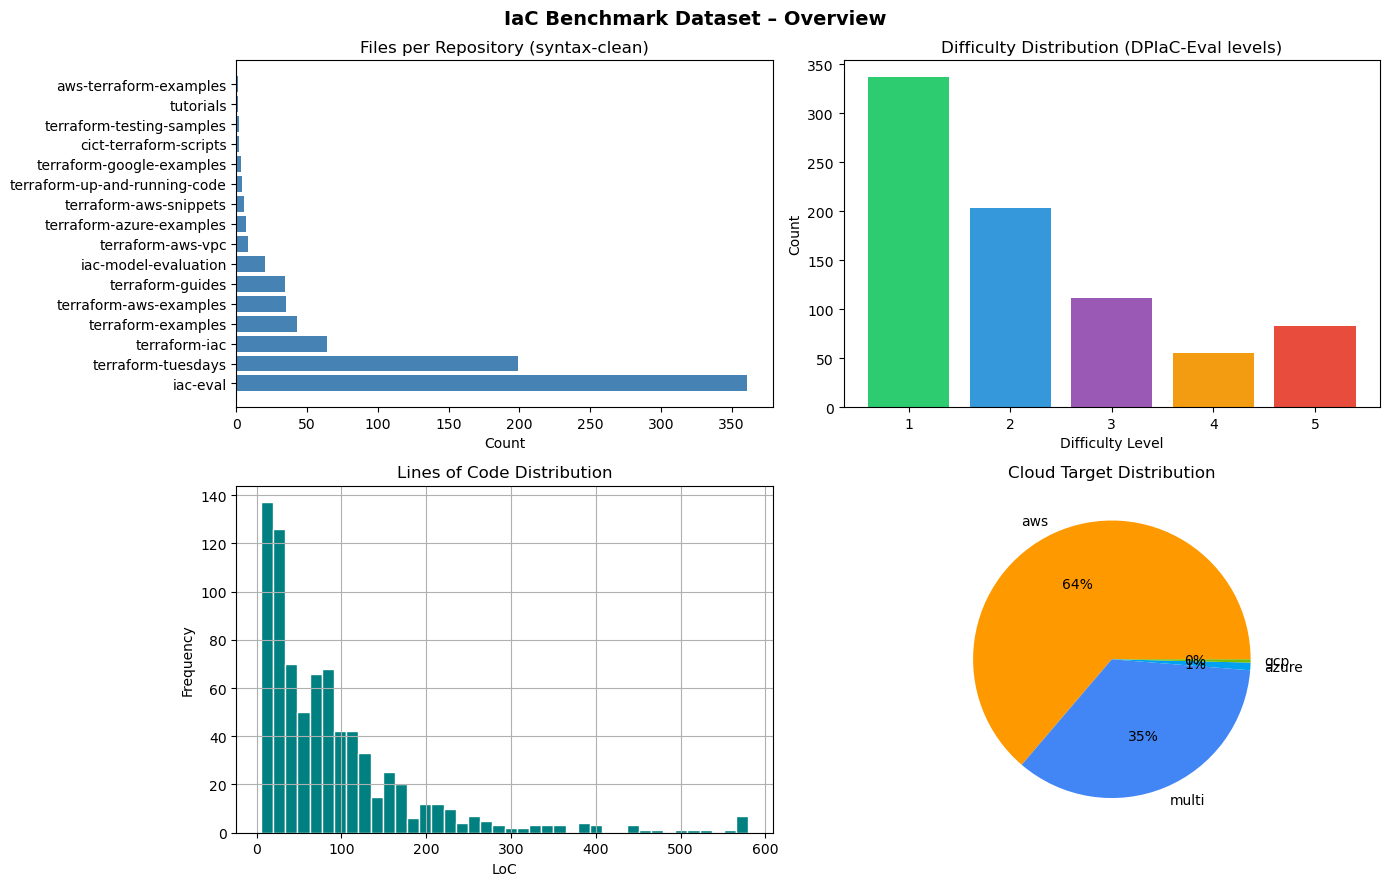

Saved: dataset_overview.png


In [49]:
# ── 12. Dataset Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('IaC Benchmark Dataset – Overview', fontsize=14, fontweight='bold')

# (a) Files by repository
ax = axes[0, 0]
src = df_aws['source_slug'].str.split('/').str[-1].value_counts()
ax.barh(src.index, src.values, color='steelblue')
ax.set_title('Files per Repository (syntax-clean)')
ax.set_xlabel('Count')

# (b) Difficulty distribution
ax = axes[0, 1]
diff = df_aws['difficulty'].value_counts().sort_index()
ax.bar(diff.index.astype(str), diff.values,
       color=['#2ECC71','#3498DB','#9B59B6','#F39C12','#E74C3C'])
ax.set_title('Difficulty Distribution (DPIaC-Eval levels)')
ax.set_xlabel('Difficulty Level'); ax.set_ylabel('Count')

# (c) LOC histogram
ax = axes[1, 0]
df_aws['loc'].clip(upper=MAX_LOC).hist(bins=40, ax=ax, color='teal', edgecolor='white')
ax.set_title('Lines of Code Distribution')
ax.set_xlabel('LoC'); ax.set_ylabel('Frequency')

# (d) Cloud target pie
ax = axes[1, 1]
cloud = df_aws['primary_cloud'].value_counts()
ax.pie(cloud.values, labels=cloud.index, autopct='%1.0f%%',
       colors=['#FF9900','#4285F4','#00A1F1','#7FBA00','#EA4335'])
ax.set_title('Cloud Target Distribution')

plt.tight_layout()
plt.savefig(DATASET_DIR / 'dataset_overview.png', dpi=150)
plt.show()
print('Saved: dataset_overview.png')


In [ ]:
# !conda install -c plotly plotly-orca

In [51]:
# ── 13. Dataset Visualisation – AWS Service Distribution & Complexity Table ───
# Saves PNGs via matplotlib.pyplot.savefig (no kaleido needed).

import hcl2, io, re, json
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')   # non-interactive backend — no display needed
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from tqdm.notebook import tqdm

DATASET_DIR.mkdir(parents=True, exist_ok=True)

# ── SERVICE_PREFIXES: covers all ~1615 resources in hashicorp/aws provider ────
SERVICE_PREFIXES = {
    # Compute
    'instance': 'EC2', 'ami': 'EC2', 'ebs': 'EC2', 'ec2': 'EC2',
    'spot': 'EC2', 'placement': 'EC2', 'key_pair': 'EC2',
    'launch': 'EC2', 'network_interface': 'EC2', 'volume': 'EC2',
    'elastic_ip': 'EC2', 'eip': 'EC2', 'fleet': 'EC2',
    # Networking / VPC
    'vpc': 'VPC', 'subnet': 'VPC', 'internet_gateway': 'VPC',
    'nat_gateway': 'VPC', 'route_table': 'VPC', 'route': 'VPC',
    'network_acl': 'VPC', 'security_group': 'VPC', 'flow_log': 'VPC',
    'vpn': 'VPC', 'transit_gateway': 'VPC', 'dx': 'Direct Connect',
    'customer_gateway': 'VPC', 'vpn_gateway': 'VPC',
    'default_vpc': 'VPC', 'default_subnet': 'VPC', 'default_route_table': 'VPC',
    'default_security_group': 'VPC', 'default_network_acl': 'VPC',
    'egress_only_internet_gateway': 'VPC', 'main_route_table_association': 'VPC',
    'network_interface_attachment': 'VPC', 'prefix_list': 'VPC',
    'managed_prefix_list': 'VPC',
    # Storage
    's3': 'S3', 'glacier': 'Glacier', 'storage_gateway': 'Storage Gateway',
    'efs': 'EFS', 'fsx': 'FSx', 'datasync': 'DataSync',
    'backup': 'Backup', 'dlm': 'DLM',
    # Database
    'rds': 'RDS', 'db': 'RDS', 'aurora': 'RDS',
    'dynamodb': 'DynamoDB', 'dax': 'DAX',
    'elasticache': 'ElastiCache', 'memorydb': 'MemoryDB',
    'redshift': 'Redshift', 'neptune': 'Neptune',
    'docdb': 'DocumentDB', 'timestream': 'Timestream',
    'keyspaces': 'Keyspaces', 'opensearch': 'OpenSearch',
    'elasticsearch': 'OpenSearch',
    # Serverless / App Integration
    'lambda': 'Lambda', 'sfn': 'Step Functions',
    'sqs': 'SQS', 'sns': 'SNS', 'eventbridge': 'EventBridge',
    'cloudwatch': 'CloudWatch', 'events': 'EventBridge',
    'scheduler': 'EventBridge', 'pipes': 'EventBridge',
    'kinesis': 'Kinesis', 'firehose': 'Kinesis Firehose',
    'msk': 'MSK', 'kafka': 'MSK',
    # API / Frontend
    'apigateway': 'API Gateway', 'api_gateway': 'API Gateway',
    'appsync': 'AppSync', 'amplify': 'Amplify',
    'cloudfront': 'CloudFront',
    # Containers
    'ecs': 'ECS', 'ecr': 'ECR', 'eks': 'EKS',
    'app_runner': 'App Runner', 'apprunner': 'App Runner', 'batch': 'Batch',
    # IAM / Security
    'iam': 'IAM', 'organizations': 'Organizations',
    'kms': 'KMS', 'secretsmanager': 'Secrets Manager',
    'acm': 'ACM', 'acmpca': 'ACM PCA',
    'cognito': 'Cognito', 'sso': 'SSO', 'ssoadmin': 'SSO',
    'identitystore': 'SSO', 'ram': 'RAM',
    # Network Security
    'waf': 'WAF', 'wafv2': 'WAF', 'shield': 'Shield',
    'guardduty': 'GuardDuty', 'inspector': 'Inspector',
    'inspector2': 'Inspector', 'macie2': 'Macie',
    'security_hub': 'Security Hub', 'securityhub': 'Security Hub',
    'detective': 'Detective', 'fms': 'FMS',
    'network_firewall': 'Network Firewall', 'networkfirewall': 'Network Firewall',
    'verified_access': 'Verified Access',
    # Load Balancing
    'lb': 'ELB', 'alb': 'ELB', 'elb': 'ELB', 'load_balancer': 'ELB',
    # DNS
    'route53': 'Route 53', 'route53resolver': 'Route 53',
    'route53recoverycontrolconfig': 'Route 53',
    'route53recoveryreadiness': 'Route 53',
    # Monitoring / Ops
    'ssm': 'SSM', 'config': 'Config', 'cloudtrail': 'CloudTrail',
    'xray': 'X-Ray', 'fis': 'FIS',
    'service_discovery': 'Cloud Map', 'servicediscovery': 'Cloud Map',
    # Automation / DevOps
    'autoscaling': 'Auto Scaling', 'autoscalingplans': 'Auto Scaling',
    'appautoscaling': 'App Auto Scaling',
    'cloudformation': 'CloudFormation',
    'codeartifact': 'CodeArtifact', 'codecommit': 'CodeCommit',
    'codebuild': 'CodeBuild', 'codedeploy': 'CodeDeploy',
    'codepipeline': 'CodePipeline', 'codestar': 'CodeStar',
    'codestarconnections': 'CodeStar', 'codestarnotifications': 'CodeStar',
    # AI / ML
    'sagemaker': 'SageMaker', 'comprehend': 'Comprehend',
    'lex': 'Lex', 'lexv2models': 'Lex',
    'rekognition': 'Rekognition', 'transcribe': 'Transcribe',
    'bedrock': 'Bedrock', 'bedrockagent': 'Bedrock',
    # Analytics
    'athena': 'Athena', 'emr': 'EMR', 'glue': 'Glue',
    'lakeformation': 'Lake Formation', 'quicksight': 'QuickSight',
    'datapipeline': 'Data Pipeline', 'cleanrooms': 'Clean Rooms',
    # Misc
    'ses': 'SES', 'sesv2': 'SES', 'pinpoint': 'Pinpoint',
    'lightsail': 'Lightsail', 'workspaces': 'WorkSpaces',
    'appconfig': 'AppConfig', 'appconfigdata': 'AppConfig',
    'servicecatalog': 'Service Catalog',
    'resourcegroups': 'Resource Groups',
    'budgets': 'Budgets', 'ce': 'Cost Explorer', 'cur': 'Cost Explorer',
    'grafana': 'Grafana', 'prometheus': 'Prometheus',
    'location': 'Location', 'opensearchserverless': 'OpenSearch',
    'verifiedpermissions': 'Cedar', 'codecatalyst': 'CodeCatalyst',
    'ivs': 'IVS', 'ivschat': 'IVS', 'chime': 'Chime',
    'dms': 'DMS', 'mgn': 'MGN',
    'mediaconvert': 'MediaConvert', 'medialive': 'MediaLive',
    'mediapackage': 'MediaPackage', 'mediatailor': 'MediaTailor',
    'iot': 'IoT', 'iotevents': 'IoT Events', 'iotanalytics': 'IoT',
    'account': 'Account', 'savingsplans': 'Savings Plans',
}

def resource_to_service(rtype: str) -> str:
    """Derive AWS service from terraform resource type using progressive prefix lookup."""
    if not rtype.startswith('aws_'):
        return 'Non-AWS'
    parts = rtype[4:].split('_')
    for length in range(min(4, len(parts)), 0, -1):
        key = '_'.join(parts[:length])
        if key in SERVICE_PREFIXES:
            return SERVICE_PREFIXES[key]
    return parts[0].upper() if parts else 'Other'


# ── 13a. Parse AST ────────────────────────────────────────────────────────────
def parse_tf_metrics(content: str) -> dict:
    metrics = {
        'resource_count': 0, 'variable_count': 0, 'output_count': 0,
        'data_source_count': 0, 'module_count': 0, 'resource_types': [],
    }
    def _unwrap(v):
        return v[0] if isinstance(v, list) and len(v) == 1 else v

    try:
        ast = hcl2.load(io.StringIO(content))
        for block in ast.get('resource', []):
            for rtype, instances in block.items():
                metrics['resource_count'] += len(instances) if isinstance(instances, list) else 1
                metrics['resource_types'].append(rtype)
        for block in ast.get('variable', []):
            metrics['variable_count'] += len(block)
        for block in ast.get('output', []):
            metrics['output_count'] += len(block)
        for block in ast.get('data', []):
            metrics['data_source_count'] += len(block)
        for block in ast.get('module', []):
            metrics['module_count'] += len(block)
    except Exception:
        metrics['resource_count']    = len(re.findall(r'^resource\s+"[^"]*"', content, re.MULTILINE))
        metrics['variable_count']    = len(re.findall(r'^variable\s+"[^"]*"', content, re.MULTILINE))
        metrics['output_count']      = len(re.findall(r'^output\s+"[^"]*"',   content, re.MULTILINE))
        metrics['data_source_count'] = len(re.findall(r'^data\s+"[^"]*"',     content, re.MULTILINE))
        metrics['module_count']      = len(re.findall(r'^module\s+"[^"]*"',   content, re.MULTILINE))
        metrics['resource_types']    = re.findall(r'^resource\s+"([^"]*)"',   content, re.MULTILINE)
    return metrics

print('Parsing HCL2 AST…')
metrics_list = [parse_tf_metrics(c) for c in tqdm(df_aws['content'], desc='AST parse')]
df_metrics   = pd.DataFrame(metrics_list)
df_viz       = pd.concat([df_aws.reset_index(drop=True), df_metrics], axis=1)

# ── 13b. Service counts ───────────────────────────────────────────────────────
all_rtypes     = [rt for sub in df_viz['resource_types'] for rt in sub]
service_series = pd.Series([resource_to_service(rt) for rt in all_rtypes])
service_counts = service_series.value_counts()

# Unrecognised check
unrecognised = [rt for rt in all_rtypes if resource_to_service(rt) not in SERVICE_PREFIXES.values()
                and not rt.startswith('aws_')]
print(f'Unrecognised (non-aws_ prefix): {len(unrecognised)}')

TOP_N        = 20
top_services = service_counts.head(TOP_N)
other_count  = service_counts.iloc[TOP_N:].sum()
if other_count > 0:
    top_services = pd.concat([top_services, pd.Series({'Other': other_count})])

# ── 13c. Complexity table ─────────────────────────────────────────────────────
DIFFICULTY_LABELS = {1:'L1 (<50 LoC)', 2:'L2 (50–100)', 3:'L3 (100–150)',
                     4:'L4 (150–200)', 5:'L5 (>200 LoC)'}
df_viz['diff_label'] = df_viz['difficulty'].map(DIFFICULTY_LABELS)

complexity_table = (
    df_viz.groupby('diff_label')
    .agg(
        files         =('dest_file',        'count'),
        mean_loc      =('loc',               'mean'),
        median_loc    =('loc',               'median'),
        mean_tokens   =('tokens',            'mean'),
        mean_resources=('resource_count',    'mean'),
        mean_variables=('variable_count',    'mean'),
        mean_outputs  =('output_count',      'mean'),
        mean_data_src =('data_source_count', 'mean'),
        mean_modules  =('module_count',      'mean'),
    )
    .round(1)
    .reindex([DIFFICULTY_LABELS[i] for i in range(1,6)])
    .reset_index()
)
complexity_table.to_csv(DATASET_DIR / 'dataset_complexity.csv', index=False)
print(f'Saved: dataset_complexity.csv')

# ── helper: save fig as png ───────────────────────────────────────────────────
def savefig(path: str, dpi: int = 150):
    plt.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f'Saved: {path}')

# ── Figure 1: AWS Service Distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
colors  = plt.cm.tab20.colors
bars    = ax.barh(top_services.index[::-1], top_services.values[::-1],
                  color=colors[:len(top_services)])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Resource Count', fontsize=11)
ax.set_title(f'AWS Service Distribution\n'
             f'{len(df_viz):,} templates · {len(all_rtypes):,} total resources',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top_services.max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
savefig(str(DATASET_DIR / 'aws_service_distribution.png'))

# ── Figure 2: Complexity table as matplotlib table ───────────────────────────
col_labels = ['Difficulty', '#Files', 'Mean\nLoC', 'Median\nLoC',
              'Mean\nTokens', '#Resources', '#Variables',
              '#Outputs', '#DataSrc', '#Modules']
cell_data = []
for _, r in complexity_table.iterrows():
    cell_data.append([
        r['diff_label'], int(r['files']),
        f"{r['mean_loc']:.0f}", f"{r['median_loc']:.0f}",
        f"{r['mean_tokens']:.0f}",
        f"{r['mean_resources']:.1f}", f"{r['mean_variables']:.1f}",
        f"{r['mean_outputs']:.1f}", f"{r['mean_data_src']:.1f}",
        f"{r['mean_modules']:.1f}",
    ])

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tbl = ax.table(
    cellText   = cell_data,
    colLabels  = col_labels,
    loc        = 'center',
    cellLoc    = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternating row shading
for i in range(1, len(cell_data) + 1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')

ax.set_title('Template Complexity by Difficulty Level',
             fontsize=12, fontweight='bold', pad=12)
savefig(str(DATASET_DIR / 'complexity_table.png'))

# ── Figure 3: Resource count distribution by difficulty (box plot) ────────────
ordered_labels = [DIFFICULTY_LABELS[i] for i in range(1, 6)
                  if DIFFICULTY_LABELS[i] in df_viz['diff_label'].values]
data_by_diff   = [df_viz.loc[df_viz['diff_label'] == l, 'resource_count'].values
                  for l in ordered_labels]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_diff, labels=ordered_labels, patch_artist=True,
                medianprops=dict(color='#e74c3c', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
colors_box = plt.cm.Blues(np.linspace(0.35, 0.75, len(ordered_labels)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_xlabel('Difficulty Level', fontsize=11)
ax.set_ylabel('# Resources', fontsize=11)
ax.set_title('Resource Count Distribution by Difficulty\n(box=IQR, whiskers=1.5×IQR)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
savefig(str(DATASET_DIR / 'resource_distribution.png'))

print('\nAll figures saved to:', DATASET_DIR)


Parsing HCL2 AST…


AST parse:   0%|          | 0/789 [00:00<?, ?it/s]

Unrecognised (non-aws_ prefix): 1049
Saved: dataset_complexity.csv
Saved: iac_benchmark/dataset/aws_service_distribution.png
Saved: iac_benchmark/dataset/complexity_table.png
Saved: iac_benchmark/dataset/resource_distribution.png

All figures saved to: iac_benchmark/dataset


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_57340/652795090.py:278: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_diff, labels=ordered_labels, patch_artist=True,
